## Project 2: Car Price Prediction

## Project Overview

This project, titled Car Price Prediction, was a challenging yet rewarding part of my project at ejaztech.ai. The goal was to build a machine learning model to predict car prices based on various features like engine size, horsepower, and car brand. I used a dataset (CarPrice_Assignment.csv) from kaggle containing 205 car entries with 26 features, ranging from numerical attributes (e.g., enginesize, horsepower) to categorical ones (e.g., CarName, fueltype). The primary objective was to preprocess the data effectively, train regression models, and evaluate their performance to understand which factors most influence car prices.

**Purpose:** To predict car prices using machine learning regression models and explore the impact of car features on pricing.

**Objectives:**

- Clean and preprocess the dataset, handling categorical variables with high cardinality.

- Train and compare multiple regression models (Linear Regression, Ridge, Lasso).

- Evaluate model performance using metrics like R², Mean Squared Error (MSE), and Mean Absolute Error (MAE).

- Visualize and interpret results to draw meaningful conclusions.


**Technologies Used:** Python, Jupyter Notebook, Pandas, NumPy, Matplotlib, Seaborn, Plotly, Scikit-learn, Category Encoders.

## Importing Required Libraries
To ensure the project's functionality, the following Python libraries and modules were imported:

### Data Handling & Computation
- pandas as pd: Used for data manipulation and analysis with DataFrames.

- numpy as np: Provided support for numerical operations and array processing.

### Data Visualization
- matplotlib & matplotlib.pyplot as plt: Enabled static, interactive, and publication-quality visualizations.

- seaborn as sns: Enhanced statistical visualizations with built-in themes and color palettes.

- plotly.express as px: Created dynamic and interactive plots for exploratory data analysis.

- %matplotlib inline: Ensured Jupyter Notebook rendered plots directly below the code cells.

### Machine Learning & Preprocessing
- category_encoders.BinaryEncoder: Facilitated binary encoding for categorical variables.

- sklearn Modules:
  - train_test_split: Split data into training and testing sets.

  - LabelEncoder, OneHotEncoder: Handled categorical variable encoding.

  - StandardScaler: Standardized features via scaling.

  - LinearRegression, RidgeCV, LassoCV: Implemented linear, regularized (L2/L1), and cross-validated regression models.

  - PolynomialFeatures: Generated polynomial terms for feature engineering.

   - r2_score, mean_squared_error, mean_absolute_error: Evaluated model performance metrics.



In [3]:
import pandas as pd 
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
from category_encoders import BinaryEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
%matplotlib inline

In [5]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

## Exploratory Data Analysis (EDA)
## Data Loading
I loaded the dataset into a structured pandas DataFrame

To thoroughly understand the dataset’s composition, I performed the following checks:

- Using df.info() for Feature Inspection
I executed the df.info() method to retrieve a comprehensive summary of the DataFrame’s structure.

 This function provided the following key details:

- RangeIndex:

  - The dataset contains 205 total entries (rows), indexed from 0 to 204.

- Columns (Features):

- - There are 26 columns in total, each representing a distinct feature of the dataset.

- Data Types:

The output displayed the data type of each column, such as:

- int64: Integer values (e.g., horsepower, citympg, highwaympg).

- float64: Floating-point numbers (e.g., boreratio, stroke, compressionratio).

- object: Typically strings or categorical data (e.g., carname, fueltype, aspiration).

- Memory Usage:

The DataFrame consumes approximately 41.8 kb of memory, which helps assess computational efficiency.

Missing Values:

The Non-Null Count column confirmed that all 205 features have 205 non-null entries, meaning no missing values are present. This eliminates the need for imputation or row removal (Handling missing values).

In [8]:
car_df = pd.read_csv('CarPrice_Assignment.csv')

In [9]:
car_df

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


In [10]:
car_df_info = car_df.info()
car_df_info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [11]:
stat_df = car_df.describe()
stat_df

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [13]:
stat_df.columns

Index(['car_ID', 'symboling', 'wheelbase', 'carlength', 'carwidth',
       'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [17]:
columns = [col for col in car_df.columns ]

for col in columns:
    print(car_df[col].value_counts(),"\n")

car_ID
1      1
142    1
132    1
133    1
134    1
      ..
72     1
73     1
74     1
75     1
205    1
Name: count, Length: 205, dtype: int64 

symboling
 0    67
 1    54
 2    32
 3    27
-1    22
-2     3
Name: count, dtype: int64 

CarName
toyota corona           6
toyota corolla          6
peugeot 504             6
subaru dl               4
mitsubishi mirage g4    3
                       ..
mazda glc 4             1
mazda rx2 coupe         1
maxda glc deluxe        1
maxda rx3               1
volvo 246               1
Name: count, Length: 147, dtype: int64 

fueltype
gas       185
diesel     20
Name: count, dtype: int64 

aspiration
std      168
turbo     37
Name: count, dtype: int64 

doornumber
four    115
two      90
Name: count, dtype: int64 

carbody
sedan          96
hatchback      70
wagon          25
hardtop         8
convertible     6
Name: count, dtype: int64 

drivewheel
fwd    120
rwd     76
4wd      9
Name: count, dtype: int64 

enginelocation
front    202
rear   

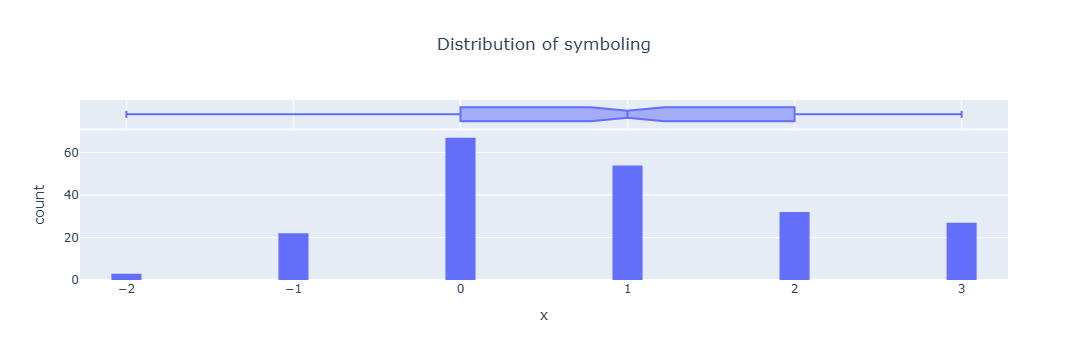

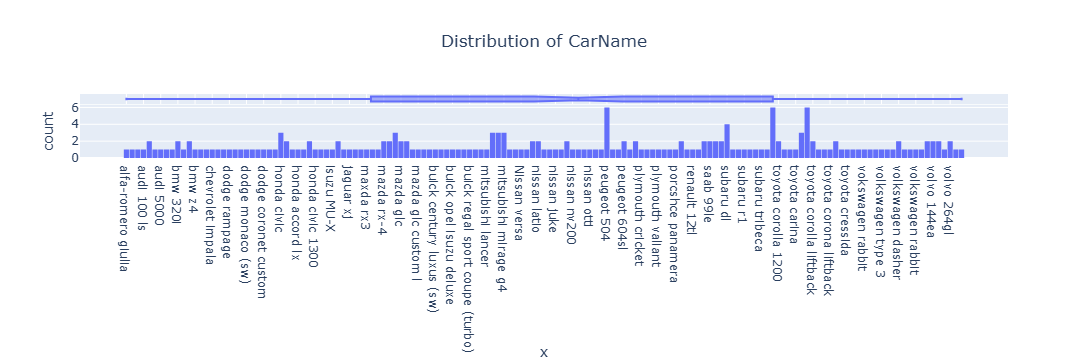

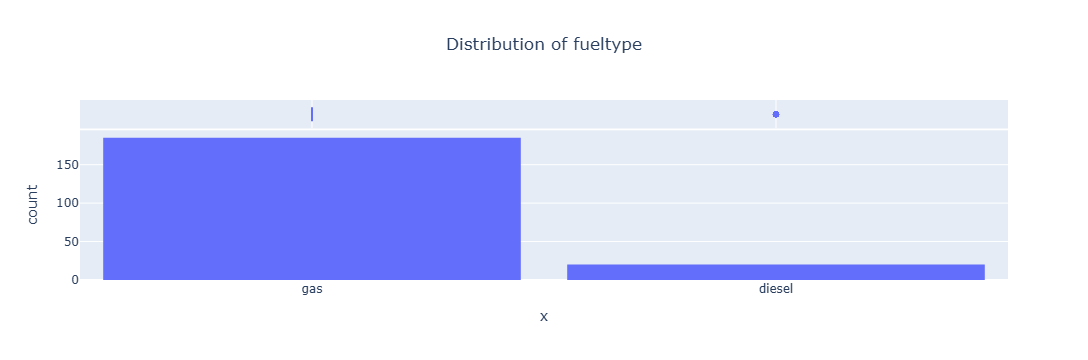

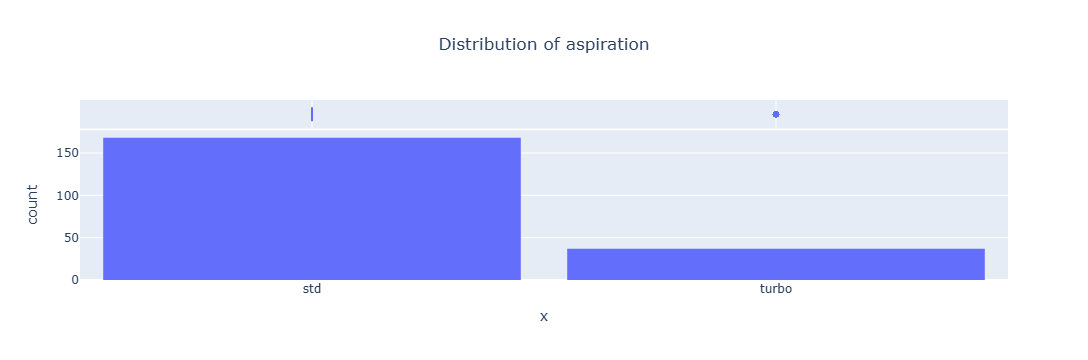

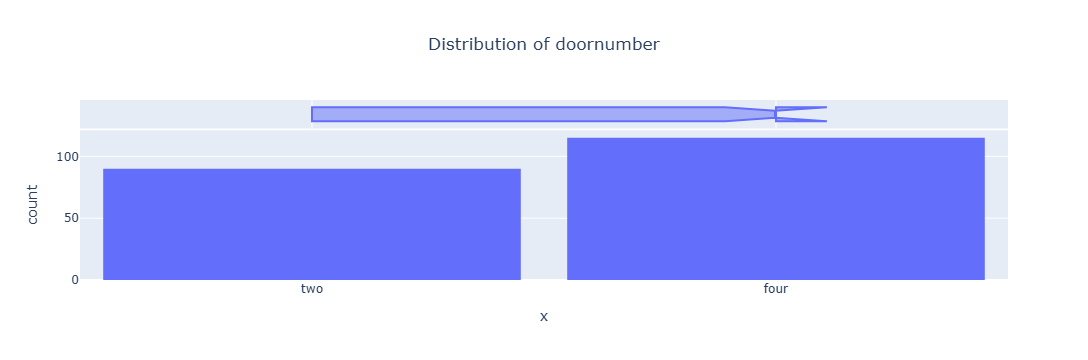

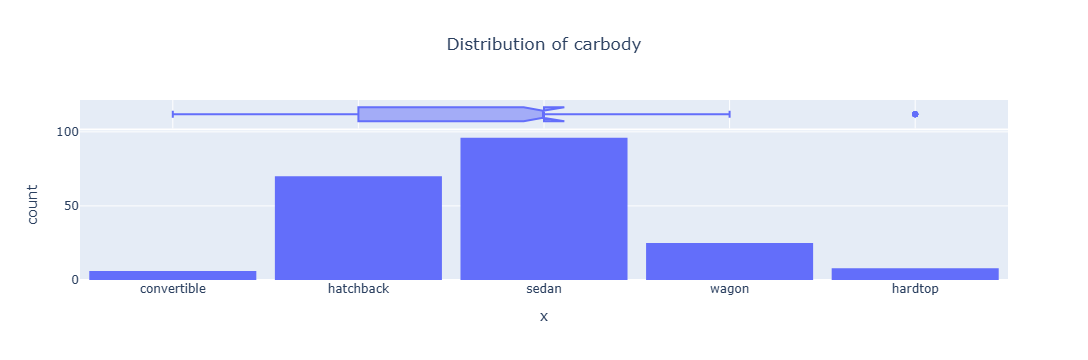

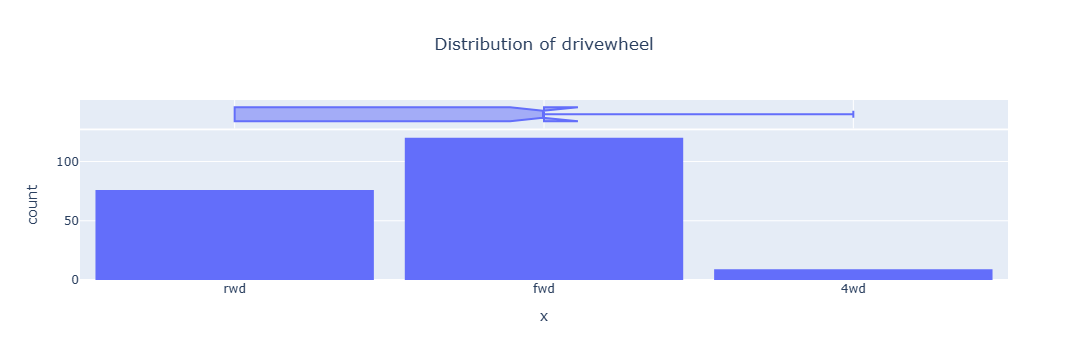

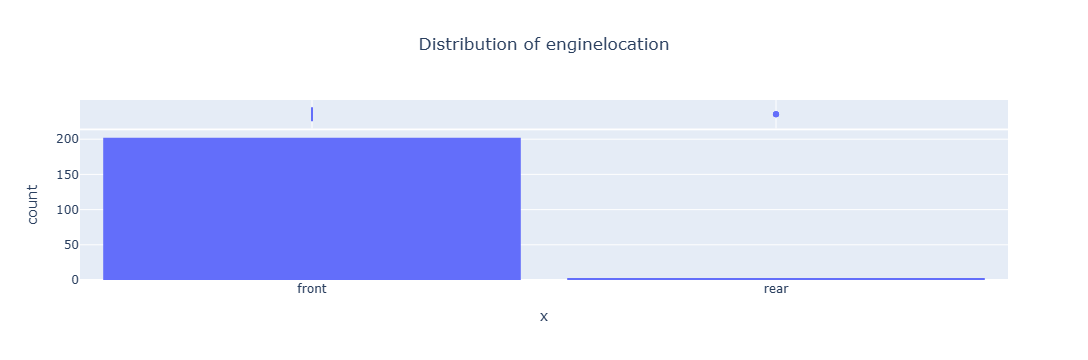

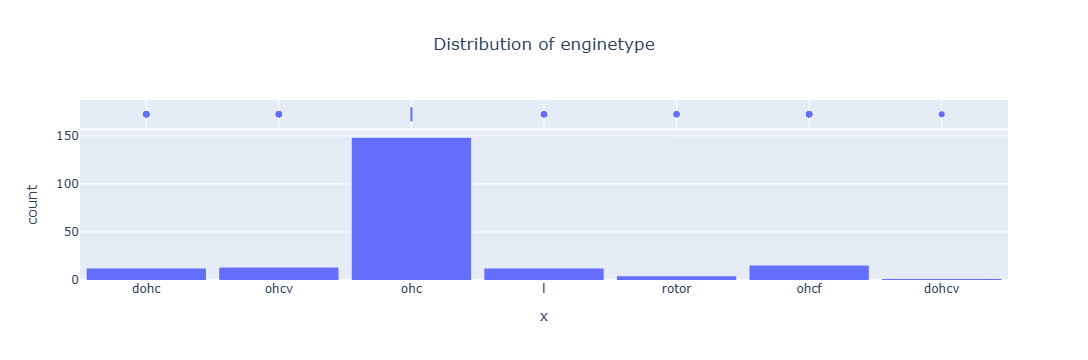

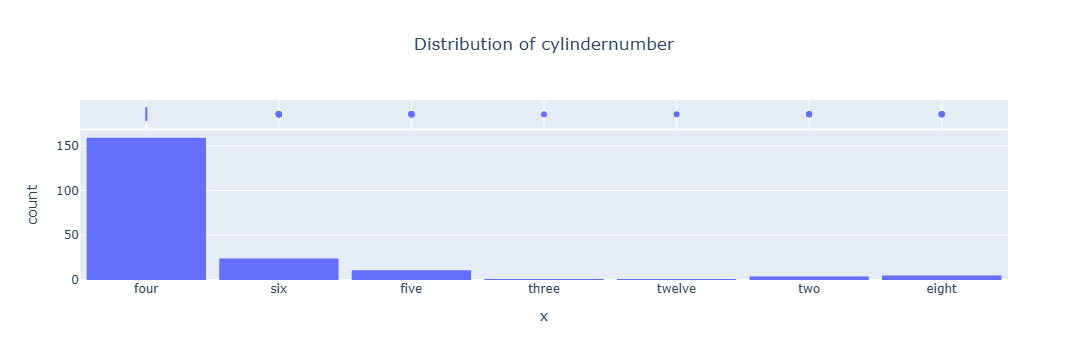

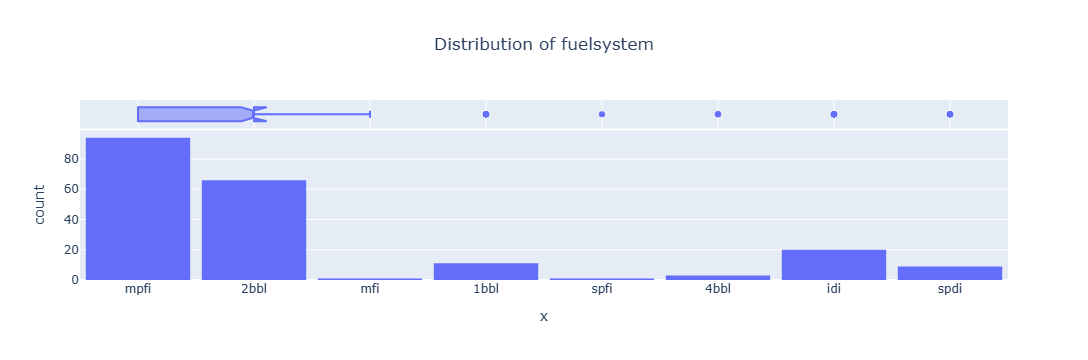

In [20]:
categorical_features = ['symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']

for feature in categorical_features:
    plt.figure(figsize=(19, 5))  
    fig = px.histogram(
        x=car_df[feature],
        marginal='box',
        nbins=47,
        title=f'Distribution of {feature}'  
    )
    
    fig.update_layout(bargap=0.1,
                     title_x=0.5
    )
    fig.show()

<Figure size 1900x500 with 0 Axes>

<Figure size 1900x500 with 0 Axes>

<Figure size 1900x500 with 0 Axes>

<Figure size 1900x500 with 0 Axes>

<Figure size 1900x500 with 0 Axes>

...

<Figure size 1900x500 with 0 Axes>

<Figure size 1900x500 with 0 Axes>

<Figure size 1900x500 with 0 Axes>

<Figure size 1900x500 with 0 Axes>

<Figure size 1900x500 with 0 Axes>

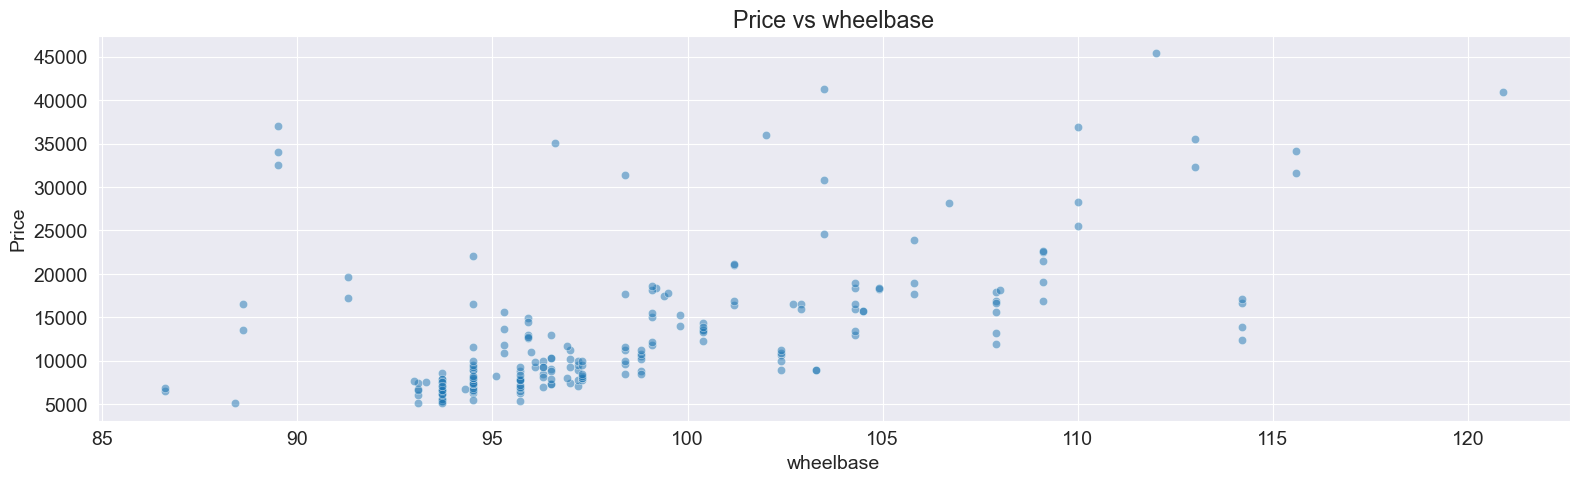

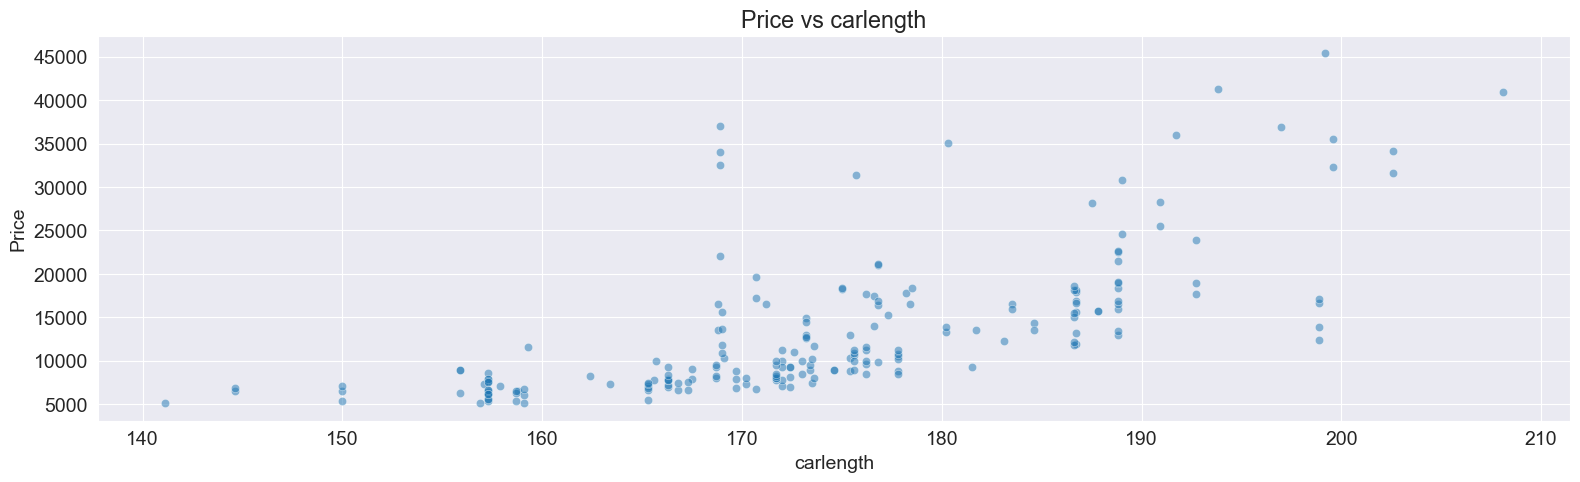

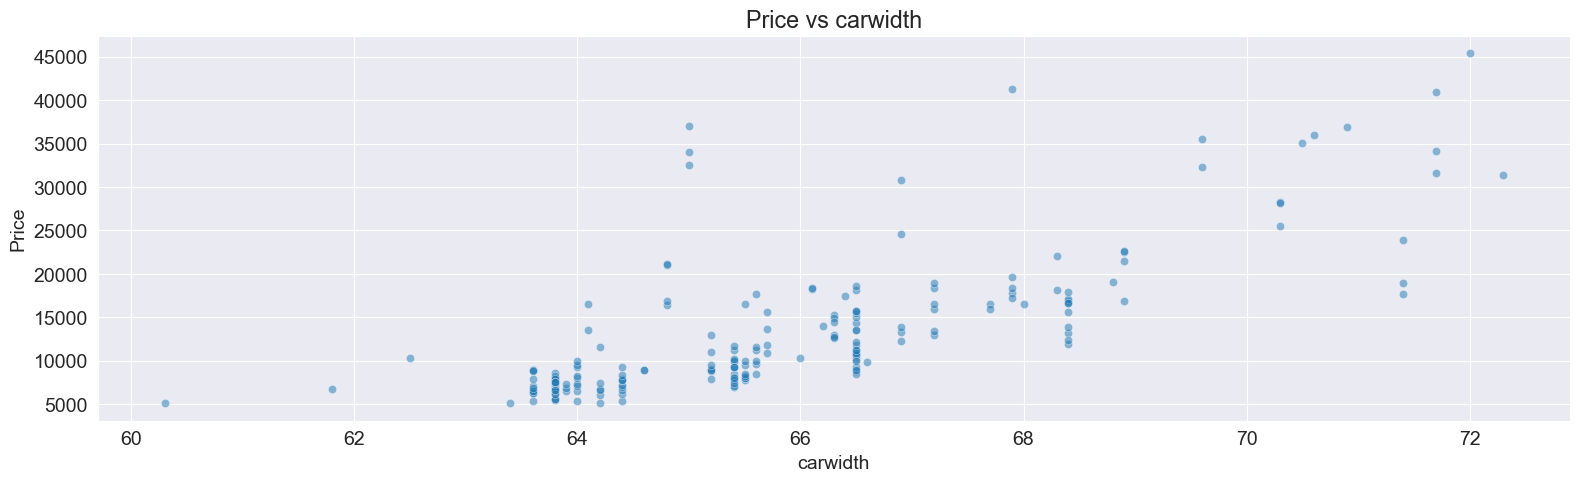

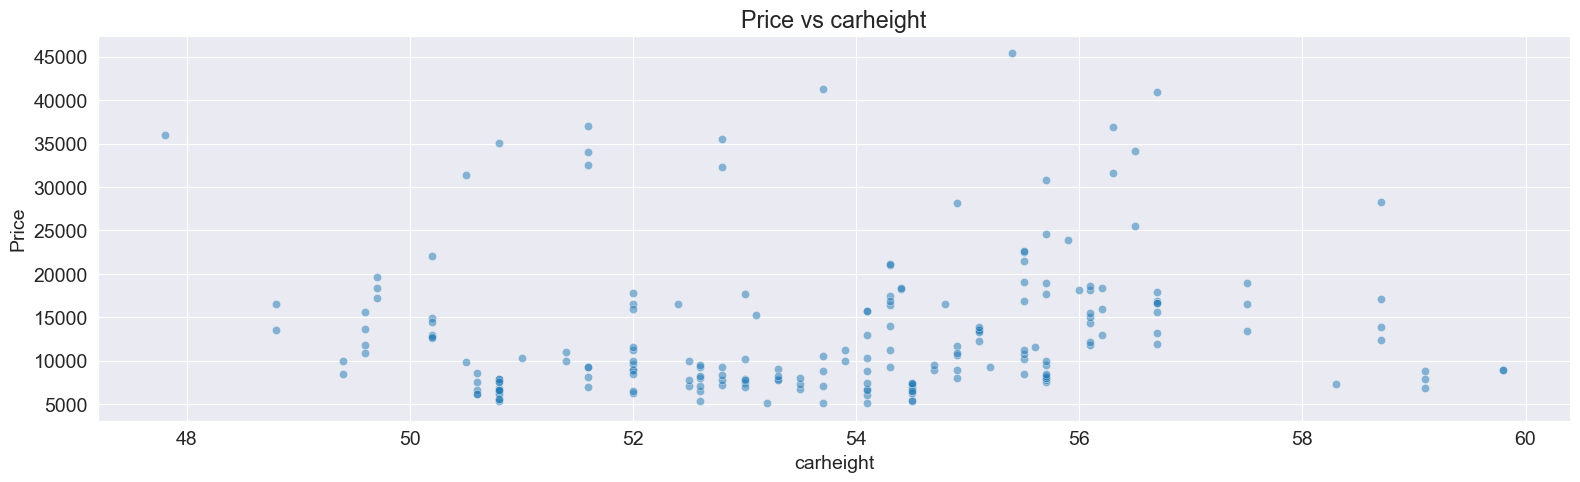

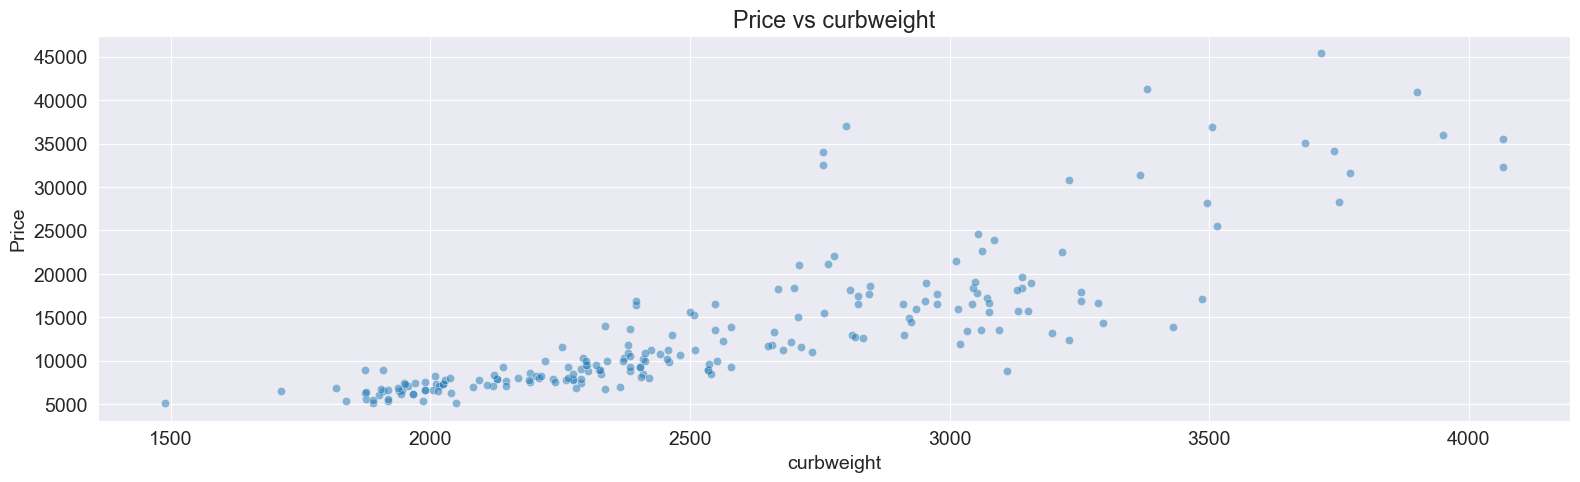

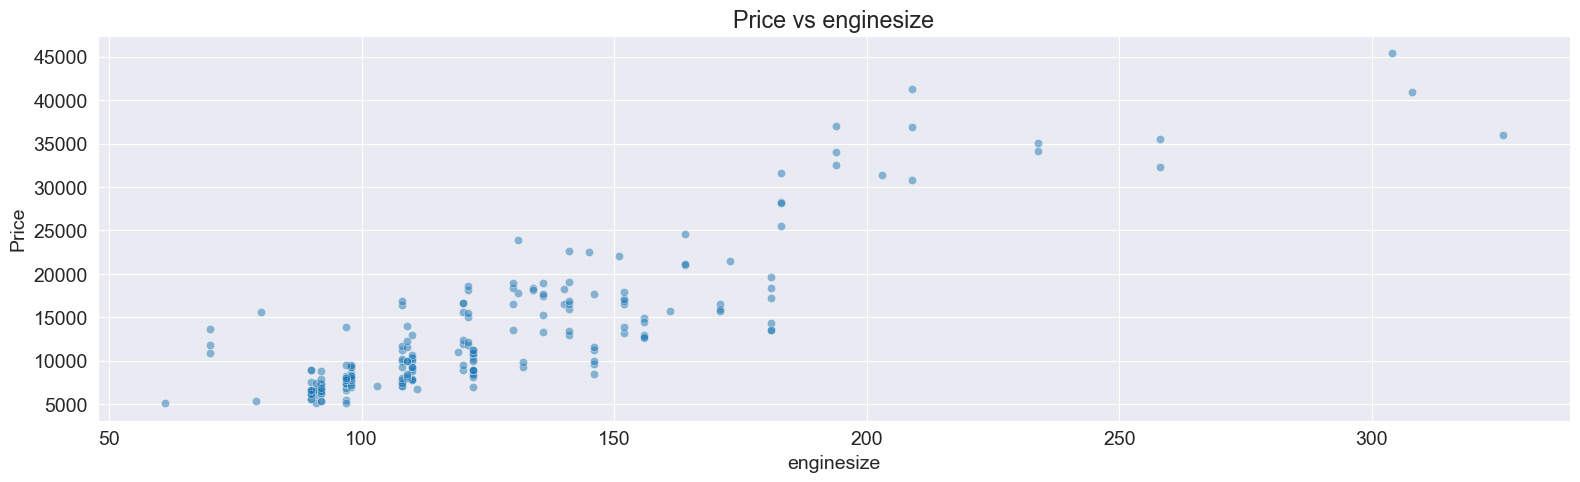

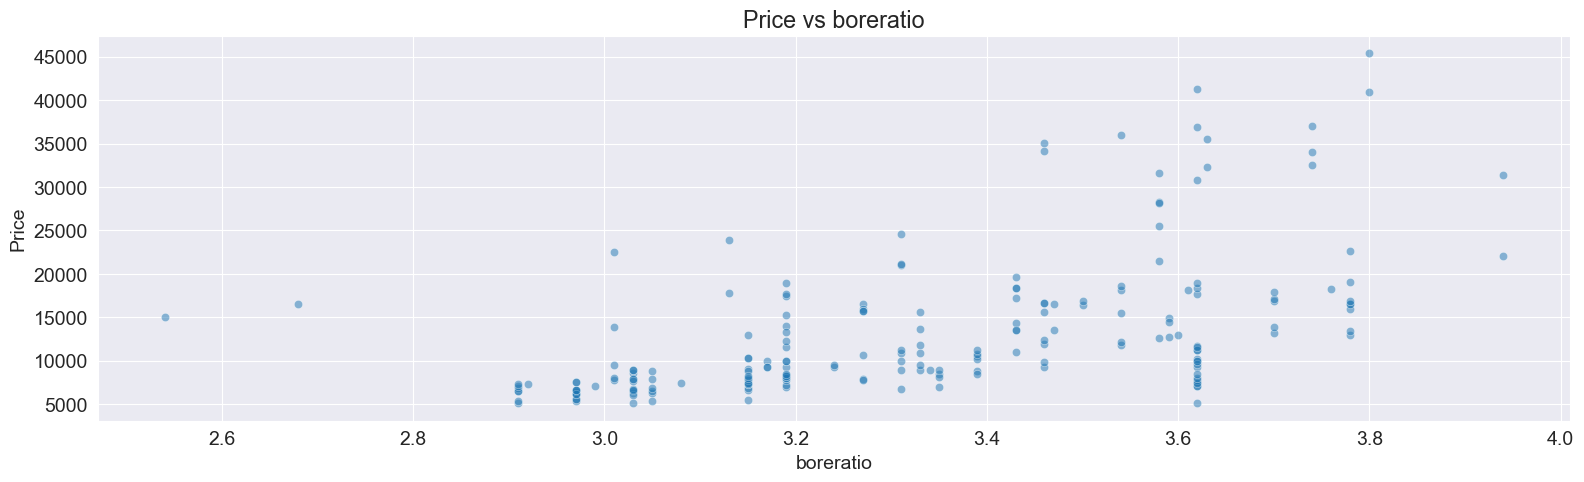

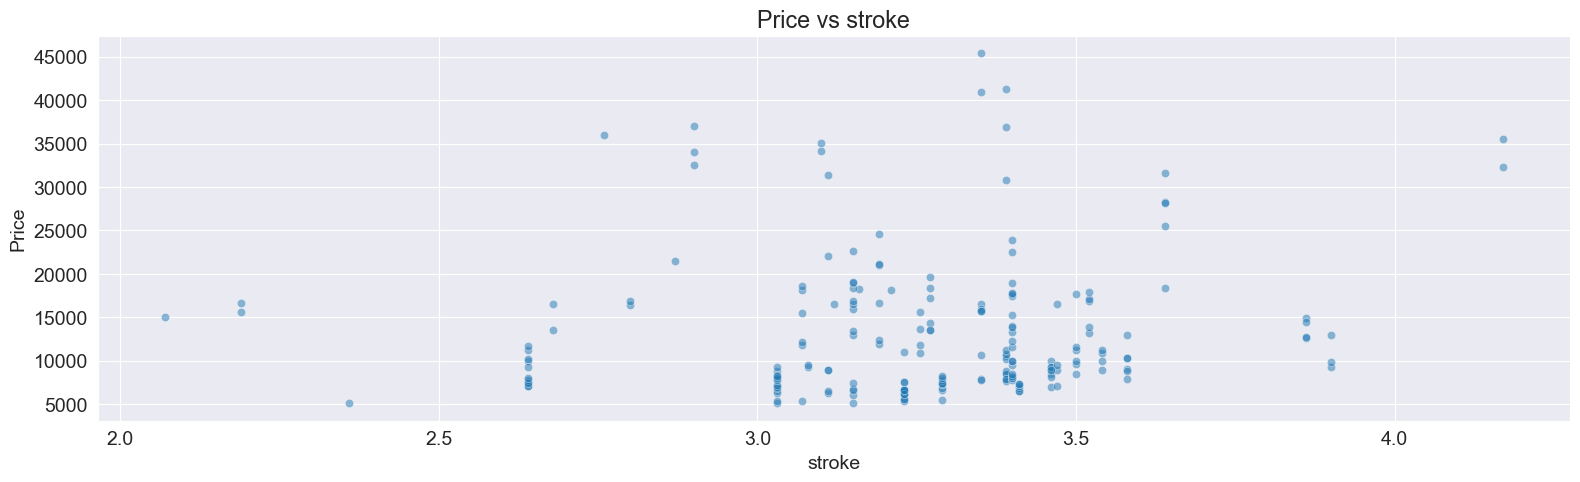

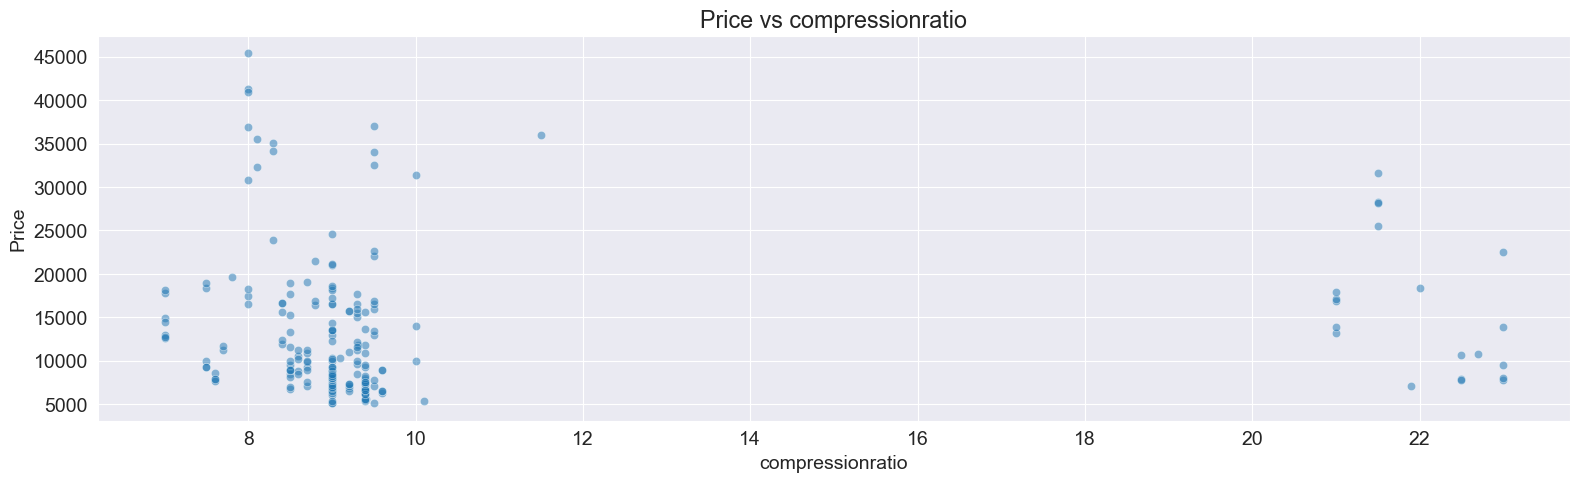

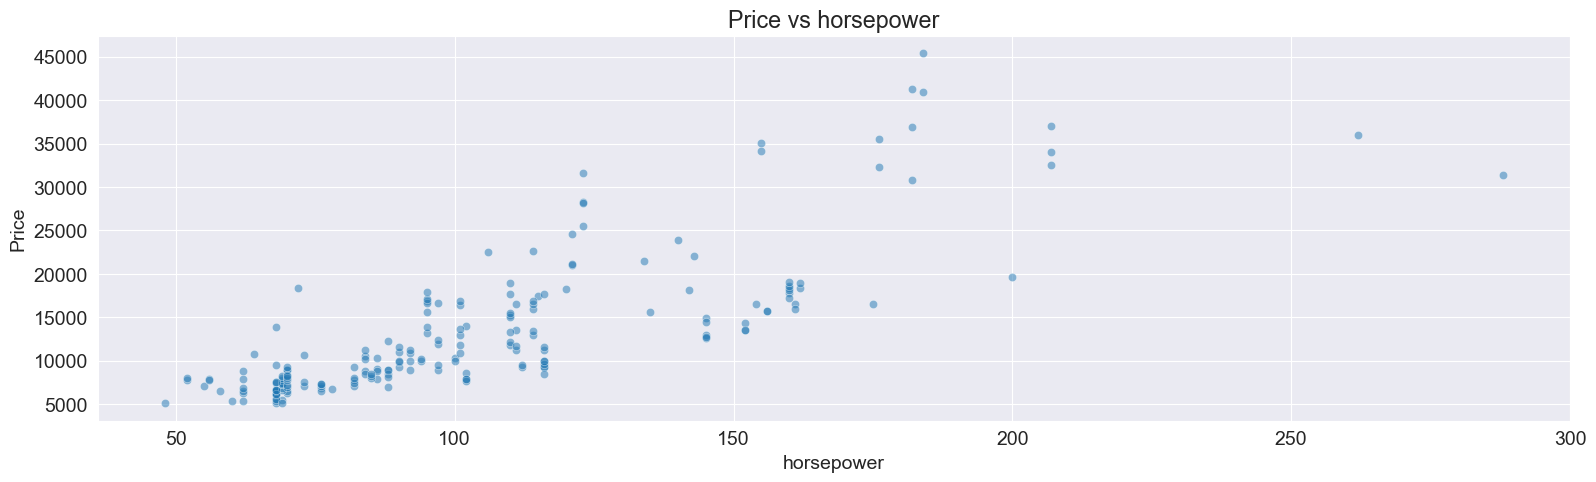

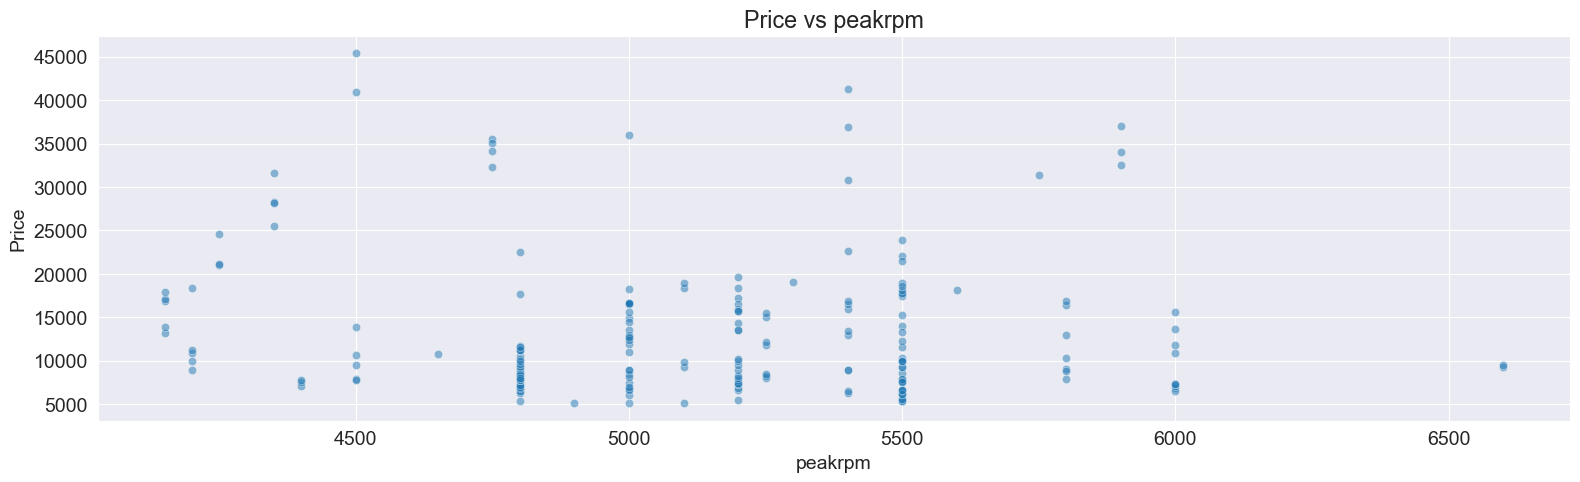

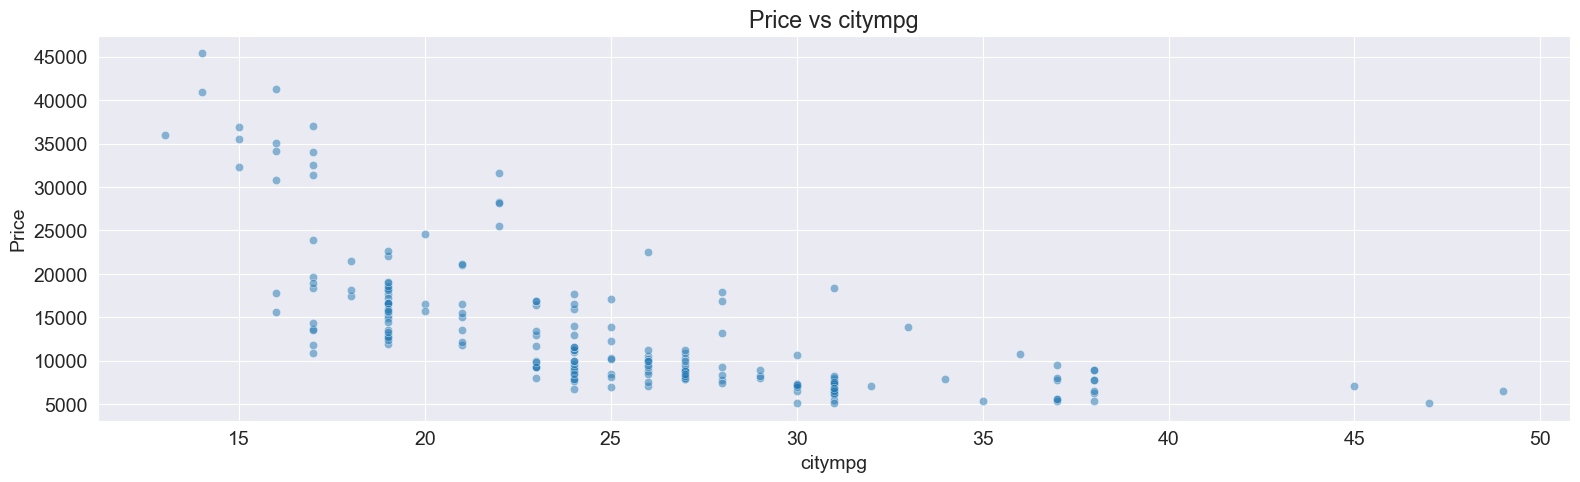

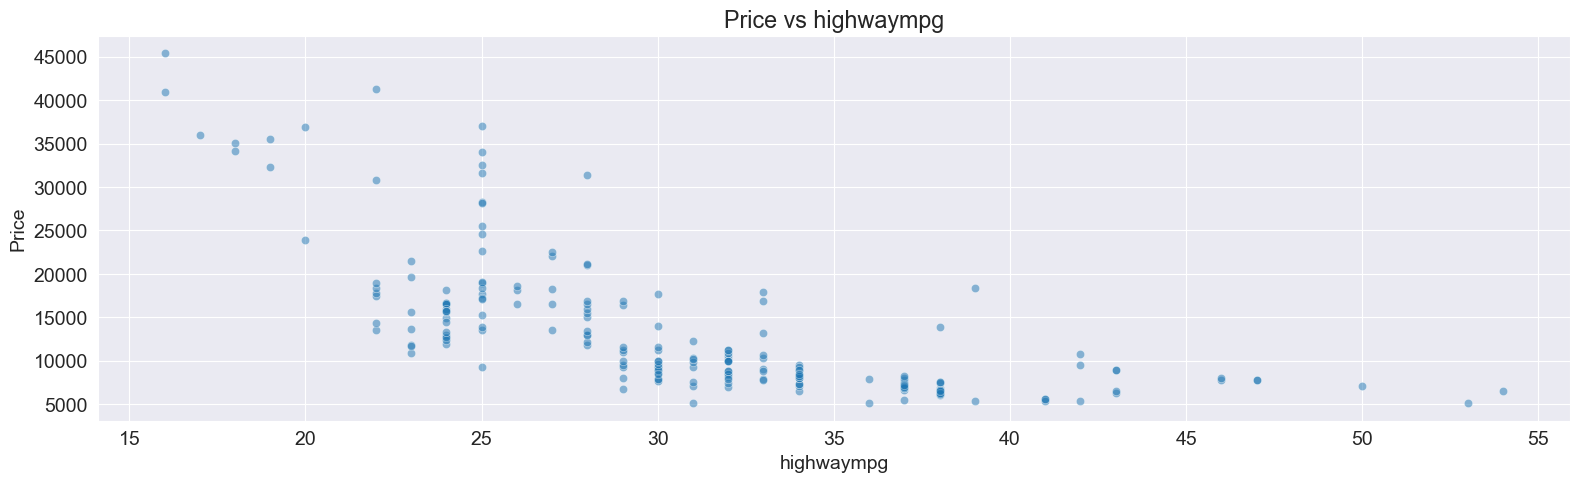

In [22]:
continous_features = [ 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 
                      'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg'
                     ]
for features in continous_features:
    plt.figure(figsize=(19, 5))
    sns.scatterplot(x=car_df[features], y=car_df['price'], alpha=0.5)
    plt.title(f'Price vs {features}')
    plt.xlabel(features)
    plt.ylabel('Price')
    plt.show()

In [24]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

## Data Preprocessing

Preprocessing was the most challenging part of the project, especially handling categorical variables and ensuring consistency between training and test sets.

I split the data into training and test sets before preprocessing to prevent data leakage. I used BinaryEncoder to encode high-cardinality categorical features like CarName and others (e.g., fueltype, carbody). I scaled numerical features using StandardScaler to ensure consistent ranges for model training.


The CarName feature was particularly tricky. I believed car brands and models (e.g., luxury brands) would significantly impact prices, so encoding it was essential than dropping it. However, CarName had many unique values and it is categorical not continous, making one-hot encoding impractical due to the high number of resulting columns. After researching many encodings, I chose binary encoding because it efficiently handles high-cardinality features by creating fewer columns while preserving information. I also learned that splitting data before preprocessing is best practice to avoid leakage, but this led to a major challenge: the encoded training and test sets had different numbers of columns due to unseen categories in the test set. I spent significant time debugging this and, morealso, ensuring the encoder was applied consistently by fitting it on the training set only and transforming the test set to avoid dataleakage as discussed earlier. Scaling numerical features was necessary because regression models are sensitive to feature scales.

In [27]:
car_df.nunique()

car_ID              205
symboling             6
CarName             147
fueltype              2
aspiration            2
doornumber            2
carbody               5
drivewheel            3
enginelocation        2
wheelbase            53
carlength            75
carwidth             44
carheight            49
curbweight          171
enginetype            7
cylindernumber        7
enginesize           44
fuelsystem            8
boreratio            38
stroke               37
compressionratio     32
horsepower           59
peakrpm              23
citympg              29
highwaympg           30
price               189
dtype: int64

In [29]:
object_data = car_df[['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 
'fuelsystem']]

object_data

,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,enginetype,cylindernumber,fuelsystem
0,alfa-romero giulia,gas,std,two,convertible,rwd,front,dohc,four,mpfi
1,alfa-romero stelvio,gas,std,two,convertible,rwd,front,dohc,four,mpfi
2,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,ohcv,six,mpfi
3,audi 100 ls,gas,std,four,sedan,fwd,front,ohc,four,mpfi
4,audi 100ls,gas,std,four,sedan,4wd,front,ohc,five,mpfi
...,...,...,...,...,...,...,...,...,...,...
200,volvo 145e (sw),gas,std,four,sedan,rwd,front,ohc,four,mpfi
201,volvo 144ea,gas,turbo,four,sedan,rwd,front,ohc,four,mpfi
202,volvo 244dl,gas,std,four,sedan,rwd,front,ohcv,six,mpfi
203,volvo 246,diesel,turbo,four,sedan,rwd,front,ohc,six,idi


In [31]:
train_set, test_set = train_test_split(car_df, test_size = 0.2, random_state = 42)

In [33]:
def car_name_encoding(train_data, test_data):
    
    encoder = BinaryEncoder(cols = ['CarName', 'enginetype', 'cylindernumber'])
    encoded_train_set = encoder.fit_transform(train_set)

    encoded_test_set = encoder.transform(test_set)

    return encoded_train_set, encoded_test_set

encoded_train, encoded_test = car_name_encoding(train_set, test_set)
encoded_train


,car_ID,symboling,CarName_0,CarName_1,CarName_2,CarName_3,CarName_4,CarName_5,CarName_6,fueltype,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
66,67,0,0,0,0,0,0,0,1,diesel,...,134,idi,3.43,3.64,22.0,72,4200,31,39,18344.0
111,112,0,0,0,0,0,0,1,0,gas,...,120,mpfi,3.46,2.19,8.4,95,5000,19,24,15580.0
153,154,0,0,0,0,0,0,1,1,gas,...,92,2bbl,3.05,3.03,9.0,62,4800,31,37,6918.0
96,97,1,0,0,0,0,1,0,0,gas,...,97,2bbl,3.15,3.29,9.4,69,5200,31,37,7499.0
38,39,0,0,0,0,0,1,0,1,gas,...,110,1bbl,3.15,3.58,9.0,86,5800,27,33,9095.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,107,1,1,1,1,1,0,1,0,gas,...,181,mpfi,3.43,3.27,9.0,160,5200,19,25,18399.0
14,15,1,1,1,1,1,0,1,1,gas,...,164,mpfi,3.31,3.19,9.0,121,4250,20,25,24565.0
92,93,1,0,0,0,0,1,0,0,gas,...,97,2bbl,3.15,3.29,9.4,69,5200,31,37,6849.0
179,180,3,1,0,1,0,1,0,0,gas,...,171,mpfi,3.27,3.35,9.3,161,5200,19,24,15998.0


In [35]:
encoded_test

,car_ID,symboling,CarName_0,CarName_1,CarName_2,CarName_3,CarName_4,CarName_5,CarName_6,fueltype,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
15,16,0,0,0,0,0,0,0,0,gas,...,209,mpfi,3.62,3.390,8.00,182,5400,16,22,30760.000
9,10,0,0,0,0,0,0,0,0,gas,...,131,mpfi,3.13,3.400,7.00,160,5500,16,22,17859.167
100,101,0,0,0,0,0,0,0,0,gas,...,120,2bbl,3.33,3.470,8.50,97,5200,27,34,9549.000
132,133,3,0,1,0,0,1,1,0,gas,...,121,mpfi,3.54,3.070,9.31,110,5250,21,28,11850.000
68,69,-1,0,0,0,0,0,0,0,diesel,...,183,idi,3.58,3.640,21.50,123,4350,22,25,28248.000
95,96,1,0,0,0,0,0,0,0,gas,...,97,2bbl,3.15,3.290,9.40,69,5200,31,37,7799.000
159,160,0,0,0,0,1,1,0,1,diesel,...,110,idi,3.27,3.350,22.50,56,4500,38,47,7788.000
162,163,0,0,0,1,0,1,1,0,gas,...,98,2bbl,3.19,3.030,9.00,70,4800,28,34,9258.000
147,148,0,0,0,0,0,0,0,0,gas,...,108,mpfi,3.62,2.640,9.00,94,5200,25,31,10198.000
182,183,2,0,0,0,0,0,0,0,diesel,...,97,idi,3.01,3.400,23.00,52,4800,37,46,7775.000


In [37]:
encoded_train.columns

Index(['car_ID', 'symboling', 'CarName_0', 'CarName_1', 'CarName_2',
       'CarName_3', 'CarName_4', 'CarName_5', 'CarName_6', 'fueltype',
       'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation',
       'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight',
       'enginetype_0', 'enginetype_1', 'enginetype_2', 'cylindernumber_0',
       'cylindernumber_1', 'cylindernumber_2', 'enginesize', 'fuelsystem',
       'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm',
       'citympg', 'highwaympg', 'price'],
      dtype='object')

In [39]:
def one_hot_encode_train_test(train_df, test_df, categorical_columns):
    """
    Performs consistent one-hot encoding on train and test sets and returns DataFrames
    
    Parameters:
    -----------
    train_df : pd.DataFrame
        Training DataFrame
    test_df : pd.DataFrame
        Test DataFrame
    categorical_columns : list
        List of column names to be one-hot encoded
        
    Returns:
    --------
    tuple: (train_encoded_df, test_encoded_df, encoder)
        Encoded DataFrames and fitted encoder
    """
    
    # Validating inputs
    if not isinstance(categorical_columns, list):
        categorical_columns = [categorical_columns]
    
    # Creating copies to avoid modifying original DataFrames
    train_encoded = train_df.copy()
    test_encoded = test_df.copy()
    
    # Initializing encoder
    encoder = OneHotEncoder(sparse_output=False,
                          handle_unknown='ignore',
                          drop='if_binary')
    
    # Fiting only on training data to avoid data leakage
    encoder.fit(train_df[categorical_columns])
    
    # Transforming both datasets (Training and test set)
    train_encoded_array = encoder.transform(train_df[categorical_columns])
    test_encoded_array = encoder.transform(test_df[categorical_columns])
    
    # Getting feature names
    feature_names = encoder.get_feature_names_out(categorical_columns)
    
    # Creating DataFrames from encoded arrays meaning turning it back to pandas dataframe 
    train_encoded_df = pd.DataFrame(train_encoded_array,
                                  columns=feature_names,
                                  index=train_df.index)
    
    test_encoded_df = pd.DataFrame(test_encoded_array,
                                 columns=feature_names,
                                 index=test_df.index)
    
    # Droping original categorical columns
    train_encoded = train_encoded.drop(categorical_columns, axis=1)
    test_encoded = test_encoded.drop(categorical_columns, axis=1)
    
    # Concatenating with non-categorical features
    train_final = pd.concat([train_encoded, train_encoded_df], axis=1)
    test_final = pd.concat([test_encoded, test_encoded_df], axis=1)
    
    return train_final, test_final, encoder

In [41]:
def get_categorical_features(data_frame, max_unique=10, exclude_columns=None):
    """
    Identifies categorical columns in a DataFrame based on dtype and uniqueness.
    
    Parameters:
    -----------
    data_frame : pd.DataFrame
        Input DataFrame
    max_unique : int (default=10)
        Maximum number of unique values to consider a column categorical
    exclude_columns : list (optional)
        Columns to exclude from consideration
        
    Returns:
    --------
    list
        Names of categorical columns
    """
    if exclude_columns is None:
        exclude_columns = []
    
    categorical_columns = []
    
    for col in data_frame.columns:
        if col in exclude_columns:
            continue
            
        # Check dtype and unique values
        is_string_or_cat = pd.api.types.is_string_dtype(data_frame[col]) or \
                          pd.api.types.is_categorical_dtype(data_frame[col])
        
        is_object = data_frame[col].dtype == 'object'
        is_low_cardinality = data_frame[col].nunique() <= max_unique
        
        if (is_string_or_cat or is_object) and is_low_cardinality:
            categorical_columns.append(col)
    
    return categorical_columns

In [43]:
def auto_encode_categorical(train_df, test_df, max_unique=10, exclude_columns=None):
    """
    Automatically detects categorical features and applies one-hot encoding
    to both train and test sets while preventing data leakage.
    
    Parameters:
    -----------
    train_df : pd.DataFrame
        Training DataFrame
    test_df : pd.DataFrame
        Test DataFrame
    max_unique : int
        Maximum unique values to consider a column categorical (default=10)
    exclude_columns : list
        Columns to exclude from encoding (e.g., IDs, targets)
        
    Returns:
    --------
    tuple: (encoded_train, encoded_test, encoder)
        Encoded DataFrames and fitted OneHotEncoder
    """
    # Step 1: Identify categorical columns
    categorical_cols = get_categorical_features(
        train_df, 
        max_unique=max_unique,
        exclude_columns=exclude_columns
    )
    
    if not categorical_cols:
        print("No categorical columns found to encode")
        return train_df, test_df, None
    
    print(f"Encoding columns: {categorical_cols}")
    
    # Step 2: Apply one-hot encoding
    encoded_train, encoded_test, encoder = one_hot_encode_train_test(
        train_df,
        test_df,
        categorical_columns=categorical_cols
    )
    
    return encoded_train, encoded_test, encoder

In [45]:
categorical_cols = get_categorical_features(encoded_train)
print(get_categorical_features(encoded_train))
print("Categorical columns:", categorical_cols)

['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'fuelsystem']
Categorical columns: ['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'fuelsystem']


In [47]:
encoded_train, encoded_test, encoder = auto_encode_categorical(
    encoded_train,
    encoded_test,
    exclude_columns=['id', 'price']  # Optional: exclude non-categorical columns
)

Encoding columns: ['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'fuelsystem']


In [49]:
encoded_train

,car_ID,symboling,CarName_0,CarName_1,CarName_2,CarName_3,CarName_4,CarName_5,CarName_6,wheelbase,...,drivewheel_rwd,enginelocation_rear,fuelsystem_1bbl,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
66,67,0,0,0,0,0,0,0,1,104.9,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
111,112,0,0,0,0,0,0,1,0,107.9,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
153,154,0,0,0,0,0,0,1,1,95.7,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
96,97,1,0,0,0,0,1,0,0,94.5,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
38,39,0,0,0,0,0,1,0,1,96.5,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,107,1,1,1,1,1,0,1,0,99.2,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
14,15,1,1,1,1,1,0,1,1,103.5,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
92,93,1,0,0,0,0,1,0,0,94.5,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
179,180,3,1,0,1,0,1,0,0,102.9,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [51]:
encoded_test

,car_ID,symboling,CarName_0,CarName_1,CarName_2,CarName_3,CarName_4,CarName_5,CarName_6,wheelbase,...,drivewheel_rwd,enginelocation_rear,fuelsystem_1bbl,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
15,16,0,0,0,0,0,0,0,0,103.5,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9,10,0,0,0,0,0,0,0,0,99.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
100,101,0,0,0,0,0,0,0,0,97.2,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
132,133,3,0,1,0,0,1,1,0,99.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
68,69,-1,0,0,0,0,0,0,0,110.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
95,96,1,0,0,0,0,0,0,0,94.5,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
159,160,0,0,0,0,1,1,0,1,95.7,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
162,163,0,0,0,1,0,1,1,0,95.7,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
147,148,0,0,0,0,0,0,0,0,97.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
182,183,2,0,0,0,0,0,0,0,97.3,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [53]:
encoded_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41 entries, 15 to 146
Data columns (total 49 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_ID               41 non-null     int64  
 1   symboling            41 non-null     int64  
 2   CarName_0            41 non-null     int64  
 3   CarName_1            41 non-null     int64  
 4   CarName_2            41 non-null     int64  
 5   CarName_3            41 non-null     int64  
 6   CarName_4            41 non-null     int64  
 7   CarName_5            41 non-null     int64  
 8   CarName_6            41 non-null     int64  
 9   wheelbase            41 non-null     float64
 10  carlength            41 non-null     float64
 11  carwidth             41 non-null     float64
 12  carheight            41 non-null     float64
 13  curbweight           41 non-null     int64  
 14  enginetype_0         41 non-null     int64  
 15  enginetype_1         41 non-null     int64  


In [55]:
encoded_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 164 entries, 66 to 102
Data columns (total 49 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_ID               164 non-null    int64  
 1   symboling            164 non-null    int64  
 2   CarName_0            164 non-null    int64  
 3   CarName_1            164 non-null    int64  
 4   CarName_2            164 non-null    int64  
 5   CarName_3            164 non-null    int64  
 6   CarName_4            164 non-null    int64  
 7   CarName_5            164 non-null    int64  
 8   CarName_6            164 non-null    int64  
 9   wheelbase            164 non-null    float64
 10  carlength            164 non-null    float64
 11  carwidth             164 non-null    float64
 12  carheight            164 non-null    float64
 13  curbweight           164 non-null    int64  
 14  enginetype_0         164 non-null    int64  
 15  enginetype_1         164 non-null    int64  

In [57]:
car_df.nunique()

car_ID              205
symboling             6
CarName             147
fueltype              2
aspiration            2
doornumber            2
carbody               5
drivewheel            3
enginelocation        2
wheelbase            53
carlength            75
carwidth             44
carheight            49
curbweight          171
enginetype            7
cylindernumber        7
enginesize           44
fuelsystem            8
boreratio            38
stroke               37
compressionratio     32
horsepower           59
peakrpm              23
citympg              29
highwaympg           30
price               189
dtype: int64

In [59]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

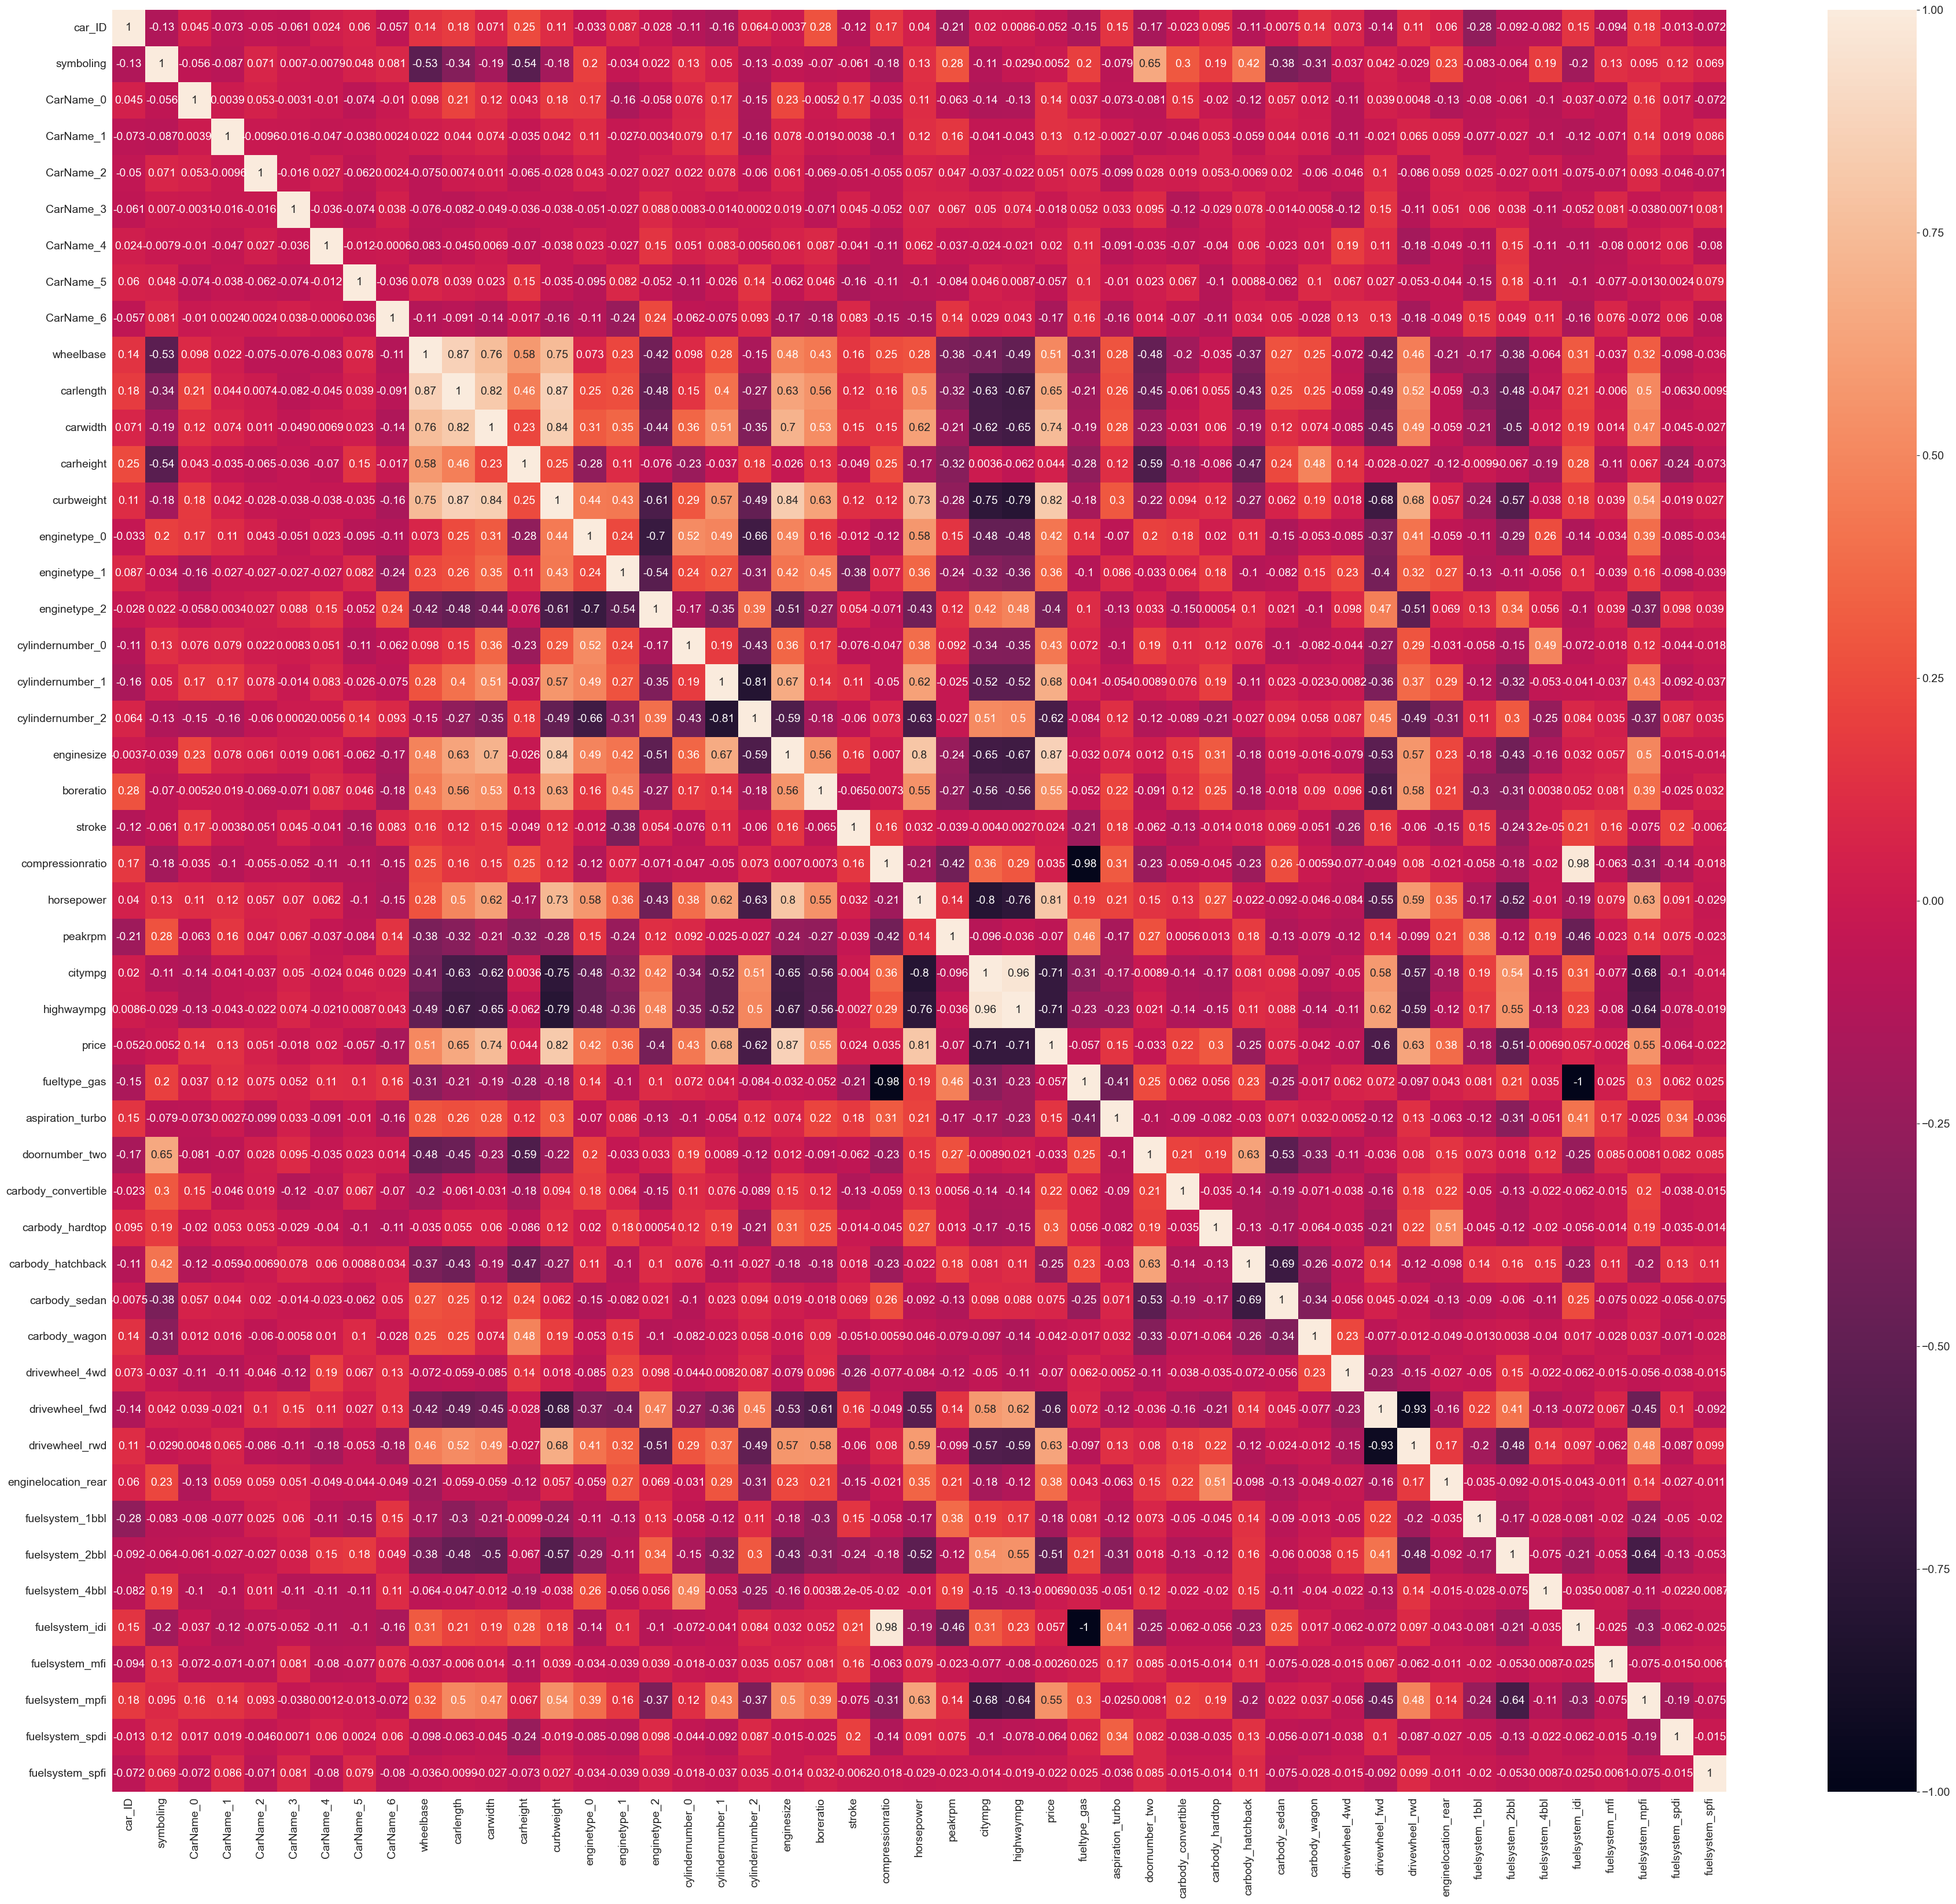

In [61]:
corr_map = encoded_train.corr()
plt.figure(figsize=(45,40))
sns.heatmap(corr_map, annot=True)
plt.show()

In [67]:
def price_features_corr(data_frame, price_column='price', correlation_threshold=(0.7, 0.15)):
    """
    Identifies features in a DataFrame based on their absolute correlation with a specified price column.

    This function calculates the Pearson correlation between all features and the price column,
    takes the absolute value of these correlations, and then categorizes the features into
    'high', 'medium', and 'low' correlation groups based on the provided thresholds.

    Args:
        data_frame (pd.DataFrame): The input Pandas DataFrame containing features and the price column.
        price_column (str, optional): The name of the column representing the price. Defaults to 'price'.
        correlation_threshold (tuple, optional): A tuple containing two float values representing the
            high and medium correlation thresholds, respectively. Features with an absolute
            correlation greater than the high threshold are considered highly correlated. Features
            with an absolute correlation between the medium threshold (exclusive) and the high
            threshold (inclusive) are considered moderately correlated. Defaults to (0.7, 0.15).

    Returns:
        dict: A dictionary containing three keys:
            'high_correlation' (list): A list of feature names with a high absolute correlation to the price.
            'medium_correlation' (list): A list of feature names with a medium absolute correlation to the price.
            'low_correlation' (list): A list of feature names with a low absolute correlation to the price.
    """
    # Calculating the correlation of all features with the specified price column.
    correlation_series = data_frame.corr()[price_column].abs().sort_values(ascending=False)

    # Unpacking the correlation thresholds for easier use.
    high_threshold, medium_threshold = correlation_threshold

    # Identify features with high absolute correlation (greater than the high threshold),
    # excluding the price column itself (which will have a correlation of 1).
    high_correlation = list(correlation_series[correlation_series > high_threshold].index[1:])

    # Identify features with medium absolute correlation (between the medium threshold (exclusive)
    # and the high threshold (inclusive)).
    medium_correlation = list(correlation_series[(correlation_series <= high_threshold) &
                                                (correlation_series > medium_threshold)].index)

    # Identify features with low absolute correlation (less than or equal to the medium threshold).
    low_correlation = list(correlation_series[(correlation_series < medium_threshold)].index)

    # Return a dictionary containing the categorized features.
    return {
        'high_correlation': high_correlation,
        'medium_correlation': medium_correlation,
        'low_correlation': low_correlation
    }

In [63]:
#Using the price features correlation function to identify high correlated features
correlation = price_features_corr(encoded_train)
correlation['high_correlation']

['enginesize', 'curbweight', 'horsepower', 'carwidth', 'highwaympg', 'citympg']

In [34]:
correlation['medium_correlation']

['cylindernumber_1',
 'carlength',
 'drivewheel_rwd',
 'cylindernumber_2',
 'drivewheel_fwd',
 'fuelsystem_mpfi',
 'boreratio',
 'fuelsystem_2bbl',
 'wheelbase',
 'cylindernumber_0',
 'enginetype_0',
 'enginetype_2',
 'enginelocation_rear',
 'enginetype_1',
 'carbody_hardtop',
 'carbody_hatchback',
 'carbody_convertible',
 'fuelsystem_1bbl',
 'CarName_6',
 'aspiration_turbo']

In [35]:
correlation['low_correlation']

['CarName_0',
 'CarName_1',
 'carbody_sedan',
 'peakrpm',
 'drivewheel_4wd',
 'fuelsystem_spdi',
 'fueltype_gas',
 'fuelsystem_idi',
 'CarName_5',
 'car_ID',
 'CarName_2',
 'carheight',
 'carbody_wagon',
 'compressionratio',
 'doornumber_two',
 'stroke',
 'fuelsystem_spfi',
 'CarName_4',
 'CarName_3',
 'fuelsystem_4bbl',
 'symboling',
 'fuelsystem_mfi']

In [36]:
encoded_train.dtypes

car_ID                   int64
symboling                int64
CarName_0                int64
CarName_1                int64
CarName_2                int64
CarName_3                int64
CarName_4                int64
CarName_5                int64
CarName_6                int64
wheelbase              float64
carlength              float64
carwidth               float64
carheight              float64
curbweight               int64
enginetype_0             int64
enginetype_1             int64
enginetype_2             int64
cylindernumber_0         int64
cylindernumber_1         int64
cylindernumber_2         int64
enginesize               int64
boreratio              float64
stroke                 float64
compressionratio       float64
horsepower               int64
peakrpm                  int64
citympg                  int64
highwaympg               int64
price                  float64
fueltype_gas           float64
aspiration_turbo       float64
doornumber_two         float64
carbody_

In [81]:
def prepare_features_and_target(train_df, test_df, target_column, columns_to_drop=None, scale_features=True):
    """
    Parameters:
    - train_df, test_df: Pre-split DataFrames
    - target_column: Name of target column
    - columns_to_drop: List of columns to remove (e.g., ['ID', 'timestamp'])
    - scale_features: Whether to scale features (default: True)
    
    Returns:
    - Processed X_train, X_test
    - y_train, y_test
    - scaler object (or None)
    """
    
    # Creating copies to avoid modifying original DataFrames
    train_df = train_df.copy()
    test_df = test_df.copy()
    
    # Separating target
    y_train = train_df.pop(target_column)
    y_test = test_df.pop(target_column)
    
    # Droping specified columns if provided
    if columns_to_drop:
        train_df = train_df.drop(columns=columns_to_drop, errors='ignore')
        test_df = test_df.drop(columns=columns_to_drop, errors='ignore')
    
    # Initializing scaler
    scaler = None
    
    if scale_features:
        scaler = StandardScaler()
        # Converting to DataFrame to preserve column names
        X_train = pd.DataFrame(scaler.fit_transform(train_df), 
                             columns=train_df.columns)
        X_test = pd.DataFrame(scaler.transform(test_df),
                            columns=test_df.columns)
        return X_train, X_test, y_train, y_test, scaler
    
    return train_df, test_df, y_train, y_test, None

In [83]:
# Using the prepare features and target function
X_train, X_test, y_train, y_test, scaler = prepare_features_and_target(
    train_df=encoded_train,
    test_df=encoded_test,
    target_column='price',
    columns_to_drop=['car_ID', 'symbolling'],
    scale_features=True
)

In [85]:
X_train

,symboling,CarName_0,CarName_1,CarName_2,CarName_3,CarName_4,CarName_5,CarName_6,wheelbase,carlength,...,drivewheel_rwd,enginelocation_rear,fuelsystem_1bbl,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
0,-0.727380,-0.917985,-0.906765,-0.906765,-0.96406,-1.024695,-0.987878,0.975900,1.037085,0.072450,...,1.266165,-0.136505,-0.254824,-0.671809,-0.111111,3.151719,-0.078326,-0.952353,-0.194871,-0.078326
1,-0.727380,-0.917985,-0.906765,-0.906765,-0.96406,-1.024695,1.012270,-1.024695,1.541231,1.043916,...,1.266165,-0.136505,-0.254824,-0.671809,-0.111111,-0.317287,-0.078326,1.050031,-0.194871,-0.078326
2,-0.727380,-0.917985,-0.906765,-0.906765,-0.96406,-1.024695,1.012270,0.975900,-0.508962,-0.367616,...,-0.789786,-0.136505,-0.254824,1.488518,-0.111111,-0.317287,-0.078326,-0.952353,-0.194871,-0.078326
3,0.078636,-0.917985,-0.906765,-0.906765,-0.96406,0.975900,-0.987878,-1.024695,-0.710620,-0.732953,...,-0.789786,-0.136505,-0.254824,1.488518,-0.111111,-0.317287,-0.078326,-0.952353,-0.194871,-0.078326
4,-0.727380,-0.917985,-0.906765,-0.906765,-0.96406,0.975900,-0.987878,0.975900,-0.374523,-0.550285,...,-0.789786,-0.136505,3.924283,-0.671809,-0.111111,-0.317287,-0.078326,-0.952353,-0.194871,-0.078326
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,0.078636,1.089342,1.102822,1.102822,1.03728,-1.024695,1.012270,-1.024695,0.079208,0.363059,...,1.266165,-0.136505,-0.254824,-0.671809,-0.111111,-0.317287,-0.078326,1.050031,-0.194871,-0.078326
160,0.078636,1.089342,1.102822,1.102822,1.03728,-1.024695,1.012270,0.975900,0.801817,1.234887,...,1.266165,-0.136505,-0.254824,-0.671809,-0.111111,-0.317287,-0.078326,1.050031,-0.194871,-0.078326
161,0.078636,-0.917985,-0.906765,-0.906765,-0.96406,0.975900,-0.987878,-1.024695,-0.710620,-0.732953,...,-0.789786,-0.136505,-0.254824,1.488518,-0.111111,-0.317287,-0.078326,-0.952353,-0.194871,-0.078326
162,1.690668,1.089342,-0.906765,1.102822,-0.96406,0.975900,-0.987878,-1.024695,0.700988,0.778216,...,1.266165,-0.136505,-0.254824,-0.671809,-0.111111,-0.317287,-0.078326,1.050031,-0.194871,-0.078326


In [40]:
y_train

66     18344.0
111    15580.0
153     6918.0
96      7499.0
38      9095.0
        ...   
106    18399.0
14     24565.0
92      6849.0
179    15998.0
102    14399.0
Name: price, Length: 164, dtype: float64

In [41]:
X_test

,symboling,CarName_0,CarName_1,CarName_2,CarName_3,CarName_4,CarName_5,CarName_6,wheelbase,carlength,...,drivewheel_rwd,enginelocation_rear,fuelsystem_1bbl,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
0,-0.727380,-0.917985,-0.906765,-0.906765,-0.96406,-1.024695,-0.987878,-1.024695,0.801817,1.234887,...,1.266165,-0.136505,-0.254824,-0.671809,-0.111111,-0.317287,-0.078326,1.050031,-0.194871,-0.078326
1,-0.727380,-0.917985,-0.906765,-0.906765,-0.96406,-1.024695,-0.987878,-1.024695,0.129623,0.338150,...,-0.789786,-0.136505,-0.254824,-0.671809,-0.111111,-0.317287,-0.078326,1.050031,-0.194871,-0.078326
2,-0.727380,-0.917985,-0.906765,-0.906765,-0.96406,-1.024695,-0.987878,-1.024695,-0.256889,-0.060400,...,-0.789786,-0.136505,-0.254824,1.488518,-0.111111,-0.317287,-0.078326,-0.952353,-0.194871,-0.078326
3,1.690668,-0.917985,1.102822,-0.906765,-0.96406,0.975900,1.012270,-1.024695,0.062403,1.035612,...,-0.789786,-0.136505,-0.254824,-0.671809,-0.111111,-0.317287,-0.078326,1.050031,-0.194871,-0.078326
4,-1.533396,-0.917985,-0.906765,-0.906765,-0.96406,-1.024695,-0.987878,-1.024695,1.894133,1.392647,...,1.266165,-0.136505,-0.254824,-0.671809,-0.111111,3.151719,-0.078326,-0.952353,-0.194871,-0.078326
5,0.078636,-0.917985,-0.906765,-0.906765,-0.96406,-1.024695,-0.987878,-1.024695,-0.710620,-0.708044,...,-0.789786,-0.136505,-0.254824,1.488518,-0.111111,-0.317287,-0.078326,-0.952353,-0.194871,-0.078326
6,-0.727380,-0.917985,-0.906765,-0.906765,1.03728,0.975900,-0.987878,0.975900,-0.508962,-0.649922,...,-0.789786,-0.136505,-0.254824,-0.671809,-0.111111,3.151719,-0.078326,-0.952353,-0.194871,-0.078326
7,-0.727380,-0.917985,-0.906765,1.102822,-0.96406,0.975900,1.012270,-1.024695,-0.508962,-0.649922,...,-0.789786,-0.136505,-0.254824,1.488518,-0.111111,-0.317287,-0.078326,-0.952353,-0.194871,-0.078326
8,-0.727380,-0.917985,-0.906765,-0.906765,-0.96406,-1.024695,-0.987878,-1.024695,-0.290499,-0.052097,...,-0.789786,-0.136505,-0.254824,-0.671809,-0.111111,-0.317287,-0.078326,1.050031,-0.194871,-0.078326
9,0.884652,-0.917985,-0.906765,-0.906765,-0.96406,-1.024695,-0.987878,-1.024695,-0.240084,-0.201553,...,-0.789786,-0.136505,-0.254824,-0.671809,-0.111111,3.151719,-0.078326,-0.952353,-0.194871,-0.078326


In [42]:
y_test

15     30760.000
9      17859.167
100     9549.000
132    11850.000
68     28248.000
95      7799.000
159     7788.000
162     9258.000
147    10198.000
182     7775.000
191    13295.000
164     8238.000
65     18280.000
175     9988.000
73     40960.000
152     6488.000
18      5151.000
82     12629.000
86      8189.000
143     9960.000
60      8495.000
101    13499.000
98      8249.000
30      6479.000
25      6692.000
16     41315.000
168     9639.000
195    13415.000
97      7999.000
194    12940.000
67     25552.000
120     6229.000
154     7898.000
202    21485.000
79      7689.000
69     28176.000
145    11259.000
55     10945.000
45      8916.500
84     14489.000
146     7463.000
Name: price, dtype: float64

## Model Training and Evaluation

I trained three regression models (Linear Regression, Ridge, and Lasso) and compared their performance.

I trained a standard LinearRegression model, as well as RidgeCV and LassoCV with cross-validation to select the best regularization parameter (alpha). I evaluated each model using R² (to measure explained variance), MSE (to quantify prediction error), and MAE (to assess average error magnitude).

 I chose these models because linear regression is a simple baseline, while Ridge and Lasso add regularization to handle potential overfitting and feature selection (Lasso can set coefficients to zero). I used cross-validation for Ridge and Lasso to automatically tune alpha, saving time and improving robustness. The evaluation metrics gave me a comprehensive view of model performance, with R² indicating fit quality and MSE/MAE showing error scales

In [87]:
def linear_regression_model(X_train, X_test, y_train, y_test):
    """
    Trains a linear regression model and evaluates its performance.
    
    Parameters:
    - X_train: Scaled/normalized training features (DataFrame or array)
    - X_test: Scaled/normalized testing features (DataFrame or array)
    - y_train: Training target values (unscaled)
    - y_test: Testing target values (unscaled)
    
    Returns:
    - model: Trained LinearRegression object
    - metrics: Dictionary containing evaluation metrics
    """
    
    # Initializing the Linear Regression model
    model = LinearRegression()
    
    # Training the model on the training data
    model.fit(X_train, y_train)
    
    # Making predictions on both train and test sets
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculating evaluation metrics for training set
    train_mse = mean_squared_error(y_train, y_train_pred)
    train_rmse = np.sqrt(train_mse)
    train_r2 = r2_score(y_train, y_train_pred)
    
    # Calculating evaluation metrics for test set
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # Creating a dictionary of metrics
    metrics = {
        'train': {
            'mse': train_mse,
            'rmse': train_rmse,
            'r2': train_r2
        },
        'test': {
            'mse': test_mse,
            'rmse': test_rmse,
            'r2': test_r2
        },
        'coefficients': model.coef_,
        'intercept': model.intercept_
    }
    
    return model, metrics

In [89]:
#using the linear_regression function
linear_model, metrics = linear_regression_model(
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)


In [91]:
def print_regression_metrics(metrics):
    """
    Prints all regression metrics in a human-readable format.
    
    Parameters:
    - metrics: Dictionary containing metrics (from train_and_evaluate_linear_regression)
    """
    
    print("\n" + "="*50)
    print("LINEAR REGRESSION PERFORMANCE METRICS")
    print("="*50)
    
    # Print training metrics
    print("\nTRAINING SET PERFORMANCE:")
    print(f"- MSE (Mean Squared Error): {metrics['train']['mse']:.4f}")
    print(f"- RMSE (Root Mean Squared Error): {metrics['train']['rmse']:.4f}")
    print(f"- R² Score: {metrics['train']['r2']:.4f}")
    
    # Print testing metrics
    print("\nTEST SET PERFORMANCE:")
    print(f"- MSE (Mean Squared Error): {metrics['test']['mse']:.4f}")
    print(f"- RMSE (Root Mean Squared Error): {metrics['test']['rmse']:.4f}")
    print(f"- R² Score: {metrics['test']['r2']:.4f}")
    
    # Print model coefficients
    print("\nMODEL COEFFICIENTS:")
    for feature, coef in zip(X_train.columns, metrics['coefficients']):
        print(f"- {feature}: {coef:.6f}")
    print(f"- Intercept: {metrics['intercept']:.6f}")
    
    # Print performance comparison
    print("\nPERFORMANCE COMPARISON:")
    print(f"Train R² vs Test R² Difference: {metrics['train']['r2'] - metrics['test']['r2']:.4f}")
    print(f"Train-Test RMSE Ratio: {metrics['train']['rmse']/metrics['test']['rmse']:.2f}:1")

In [58]:
linear_model, metrics = linear_regression_model(X_train, X_test, y_train, y_test)
print_regression_metrics(metrics)


LINEAR REGRESSION PERFORMANCE METRICS

TRAINING SET PERFORMANCE:
- MSE (Mean Squared Error): 3093685.9902
- RMSE (Root Mean Squared Error): 1758.8877
- R² Score: 0.9481

TEST SET PERFORMANCE:
- MSE (Mean Squared Error): 11161689.4544
- RMSE (Root Mean Squared Error): 3340.9115
- R² Score: 0.8586

MODEL COEFFICIENTS:
- symboling: 362.062052
- CarName_0: -358.411981
- CarName_1: 136.719990
- CarName_2: 27.181112
- CarName_3: -88.130384
- CarName_4: 88.006893
- CarName_5: 92.217817
- CarName_6: -243.840904
- wheelbase: 888.879012
- carlength: -626.213901
- carwidth: 1296.362725
- carheight: 350.961180
- curbweight: 2103.477491
- enginetype_0: 393.398406
- enginetype_1: -1191.093095
- enginetype_2: 1258.829654
- cylindernumber_0: 1037.471062
- cylindernumber_1: 219.026454
- cylindernumber_2: -730.059799
- enginesize: 4379.079581
- boreratio: -221.309810
- stroke: -1235.671365
- compressionratio: -3730.920318
- horsepower: -965.558132
- peakrpm: 1056.471391
- citympg: -1215.529985
- highwa

In [112]:
def regularized_regression_model(X_train, y_train, X_test, y_test, 
                         alphas=[0.01, 0.1, 1, 10, 10.5, 11, 15, 20], 
                         model_type='ridge'):
    """
    Performs regularized regression with automatic alpha tuning.
    
    Parameters:
    - X_train, y_train: Training data
    - X_test, y_test: Test data
    - alphas: List of regularization strengths to try
    - model_type: 'ridge' (L2) or 'lasso' (L1)
    
    Returns:
    - Dictionary containing:
        - model: Fitted estimator
        - test_r2: R² score on test set
        - coefficients: Series of feature coefficients
        - optimal_alpha: Selected regularization strength
    """
    # Model selection
    if model_type == 'ridge':
        model = RidgeCV(alphas=alphas, cv=5)
    elif model_type == 'lasso':
        model = LassoCV(alphas=alphas, cv=5, max_iter=10000)
    else:
        raise ValueError("model_type must be 'ridge' or 'lasso'")
    
    # Train model
    model.fit(X_train, y_train)
    
    # Evaluate
    y_pred = model.predict(X_test)
    test_r2 = r2_score(y_test, y_pred)
    
    # Package results
    return {
        'model': model,
        'test_r2': test_r2,
        'coefficients': pd.Series(model.coef_, index=X_train.columns),
        'optimal_alpha': model.alpha_
    }


ridge_results = regularized_regression_model(X_train, y_train, X_test, y_test, model_type='ridge')
lasso_results = regularized_regression_model(X_train, y_train, X_test, y_test, model_type='lasso')

In [114]:
def print_model_results(results, model_name):
    print(f"\n===== {model_name} Results =====")
    print(f"Test R²: {results['test_r2']:.4f}")
    print(f"Optimal alpha: {results['optimal_alpha']:.4f}")
    
    # Print number of non-zero coefficients
    non_zero_coefs = (results['coefficients'] != 0).sum()
    total_coefs = len(results['coefficients'])
    print(f"Coefficients: {non_zero_coefs} non-zero out of {total_coefs} ({non_zero_coefs/total_coefs:.1%})")
    
    # Print top coefficients by magnitude
    print("\nTop 5 features by importance:")
    top_coefs = results['coefficients'].abs().sort_values(ascending=False).head(5)
    for feature, coef in top_coefs.items():
        print(f"- {feature}: {results['coefficients'][feature]:.4f}")
    
    # Print bottom coefficients (closest to zero)
    print("\nBottom 5 features (least important):")
    bottom_coefs = results['coefficients'].abs().sort_values().head(5)
    for feature, coef in bottom_coefs.items():
        print(f"- {feature}: {results['coefficients'][feature]:.4f}")



In [116]:
print_model_results(ridge_results, "Ridge Regression")
print_model_results(lasso_results, "Lasso Regression")


===== Ridge Regression Results =====
Test R²: 0.8602
Optimal alpha: 10.0000
Coefficients: 47 non-zero out of 47 (100.0%)

Top 5 features by importance:
- enginesize: 2574.1869
- enginelocation_rear: 1485.2862
- curbweight: 1475.4814
- cylindernumber_0: 1180.6253
- carwidth: 1033.8410

Bottom 5 features (least important):
- doornumber_two: -18.8237
- CarName_3: -24.6712
- boreratio: -26.3835
- carbody_hardtop: 27.5017
- drivewheel_4wd: 33.4039

===== Lasso Regression Results =====
Test R²: 0.8671
Optimal alpha: 20.0000
Coefficients: 38 non-zero out of 47 (80.9%)

Top 5 features by importance:
- enginesize: 3570.9715
- curbweight: 1828.3272
- enginelocation_rear: 1613.2671
- cylindernumber_0: 1197.1539
- enginetype_1: -1140.6041

Bottom 5 features (least important):
- fuelsystem_2bbl: -0.0000
- highwaympg: 0.0000
- carbody_hatchback: -0.0000
- drivewheel_4wd: 0.0000
- compressionratio: -0.0000


## Model Comparison Visualization

I visualized the models’ performance to compare them effectively

 I used a custom function (plot_three_model_comparison) to create plots comparing the performance of Linear Regression, Ridge, and Lasso models. The plots likely included metrics like R², MSE, and MAE, and possibly prediction vs. actual value scatter plots.


Visualizing the results helped me quickly identify which model performed best. I wanted to present my findings clearly to my instructors, and plots are more intuitive than tables of numbers.

In [98]:
def plot_regularization_results(ridge_results, lasso_results, X_test, y_test):
    """
    Create visualizations for Ridge and Lasso regression results.
    
    Parameters:
    - ridge_results: Results dictionary from Ridge regression
    - lasso_results: Results dictionary from Lasso regression
    - X_test: Test features
    - y_test: Test target values
    """
    
    # Set up the figure with subplots
    fig = plt.figure(figsize=(20, 15))
    
    # 1. Coefficient comparison plot
    ax1 = plt.subplot2grid((2, 2), (0, 0))
    
    # Get top 10 most important features (by average absolute coefficient)
    ridge_coef = ridge_results['coefficients'].abs()
    lasso_coef = lasso_results['coefficients'].abs()
    
    # Average importance between both models
    avg_importance = (ridge_coef + lasso_coef) / 2
    top_features = avg_importance.sort_values(ascending=False).head(10).index
    
    # Create coefficient comparison dataframe
    coef_df = pd.DataFrame({
        'Feature': top_features,
        'Ridge': ridge_results['coefficients'][top_features],
        'Lasso': lasso_results['coefficients'][top_features]
    })
    
    # Plot coefficient comparison
    coef_df.plot(x='Feature', y=['Ridge', 'Lasso'], kind='bar', ax=ax1)
    ax1.set_title('Top 10 Feature Coefficients: Ridge vs Lasso', fontsize=14)
    ax1.set_ylabel('Coefficient Value')
    ax1.set_xlabel('Features')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    
    # 2. Prediction scatter plot
    ax2 = plt.subplot2grid((2, 2), (0, 1))
    
    # Get predictions
    y_pred_ridge = ridge_results['model'].predict(X_test)
    y_pred_lasso = lasso_results['model'].predict(X_test)
    
    # Create a dataframe with actual and predicted values
    results_df = pd.DataFrame({
        'Actual': y_test,
        'Ridge': y_pred_ridge,
        'Lasso': y_pred_lasso
    })
    
    # Plot Ridge predictions
    ax2.scatter(results_df['Actual'], results_df['Ridge'], alpha=0.6, label='Ridge', color='blue')
    ax2.scatter(results_df['Actual'], results_df['Lasso'], alpha=0.6, label='Lasso', color='red')
    
    # Add reference line
    min_val = min(results_df['Actual'].min(), results_df[['Ridge', 'Lasso']].min().min())
    max_val = max(results_df['Actual'].max(), results_df[['Ridge', 'Lasso']].max().max())
    ax2.plot([min_val, max_val], [min_val, max_val], 'k--', label='Perfect Prediction')
    
    ax2.set_title('Actual vs Predicted Values', fontsize=14)
    ax2.set_xlabel('Actual Values')
    ax2.set_ylabel('Predicted Values')
    ax2.grid(alpha=0.3)
    ax2.legend()
    
    # 3. Coefficient sparsity visualization
    ax3 = plt.subplot2grid((2, 2), (1, 0))
    
    # Create dataframe of all coefficients
    all_coefs = pd.DataFrame({
        'Feature': ridge_results['coefficients'].index,
        'Ridge': ridge_results['coefficients'].values,
        'Lasso': lasso_results['coefficients'].values
    })
    
    # Sort by average absolute coefficient
    all_coefs['Avg_Importance'] = (abs(all_coefs['Ridge']) + abs(all_coefs['Lasso'])) / 2
    all_coefs = all_coefs.sort_values('Avg_Importance', ascending=False)
    
    # Plot coefficient sparsity
    x = np.arange(len(all_coefs))
    width = 0.35
    
    ax3.bar(x - width/2, all_coefs['Ridge'], width, label='Ridge')
    ax3.bar(x + width/2, all_coefs['Lasso'], width, label='Lasso')
    
    ax3.set_title('Coefficient Values: Ridge vs Lasso (All Features)', fontsize=14)
    ax3.set_ylabel('Coefficient Value')
    ax3.set_xticks([])  # Hide x-ticks since there are too many features
    ax3.grid(axis='y', linestyle='--', alpha=0.7)
    ax3.legend()
    
    # 4. Residuals plot
    ax4 = plt.subplot2grid((2, 2), (1, 1))
    
    results_df['Ridge_Residuals'] = results_df['Actual'] - results_df['Ridge']
    results_df['Lasso_Residuals'] = results_df['Actual'] - results_df['Lasso']
    
    ax4.scatter(results_df['Ridge'], results_df['Ridge_Residuals'], alpha=0.6, label='Ridge', color='blue')
    ax4.scatter(results_df['Lasso'], results_df['Lasso_Residuals'], alpha=0.6, label='Lasso', color='red')
    
    ax4.axhline(y=0, color='k', linestyle='--')
    ax4.set_title('Residual Plot', fontsize=14)
    ax4.set_xlabel('Predicted Values')
    ax4.set_ylabel('Residuals')
    ax4.grid(alpha=0.3)
    ax4.legend()
    
    # Add a main title and adjust layout
    plt.suptitle(f'Ridge vs Lasso Regression Comparison\nRidge R² = {ridge_results["test_r2"]:.4f}, Lasso R² = {lasso_results["test_r2"]:.4f}', 
                fontsize=16, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    # Return the figure for further customization if needed
    return figa

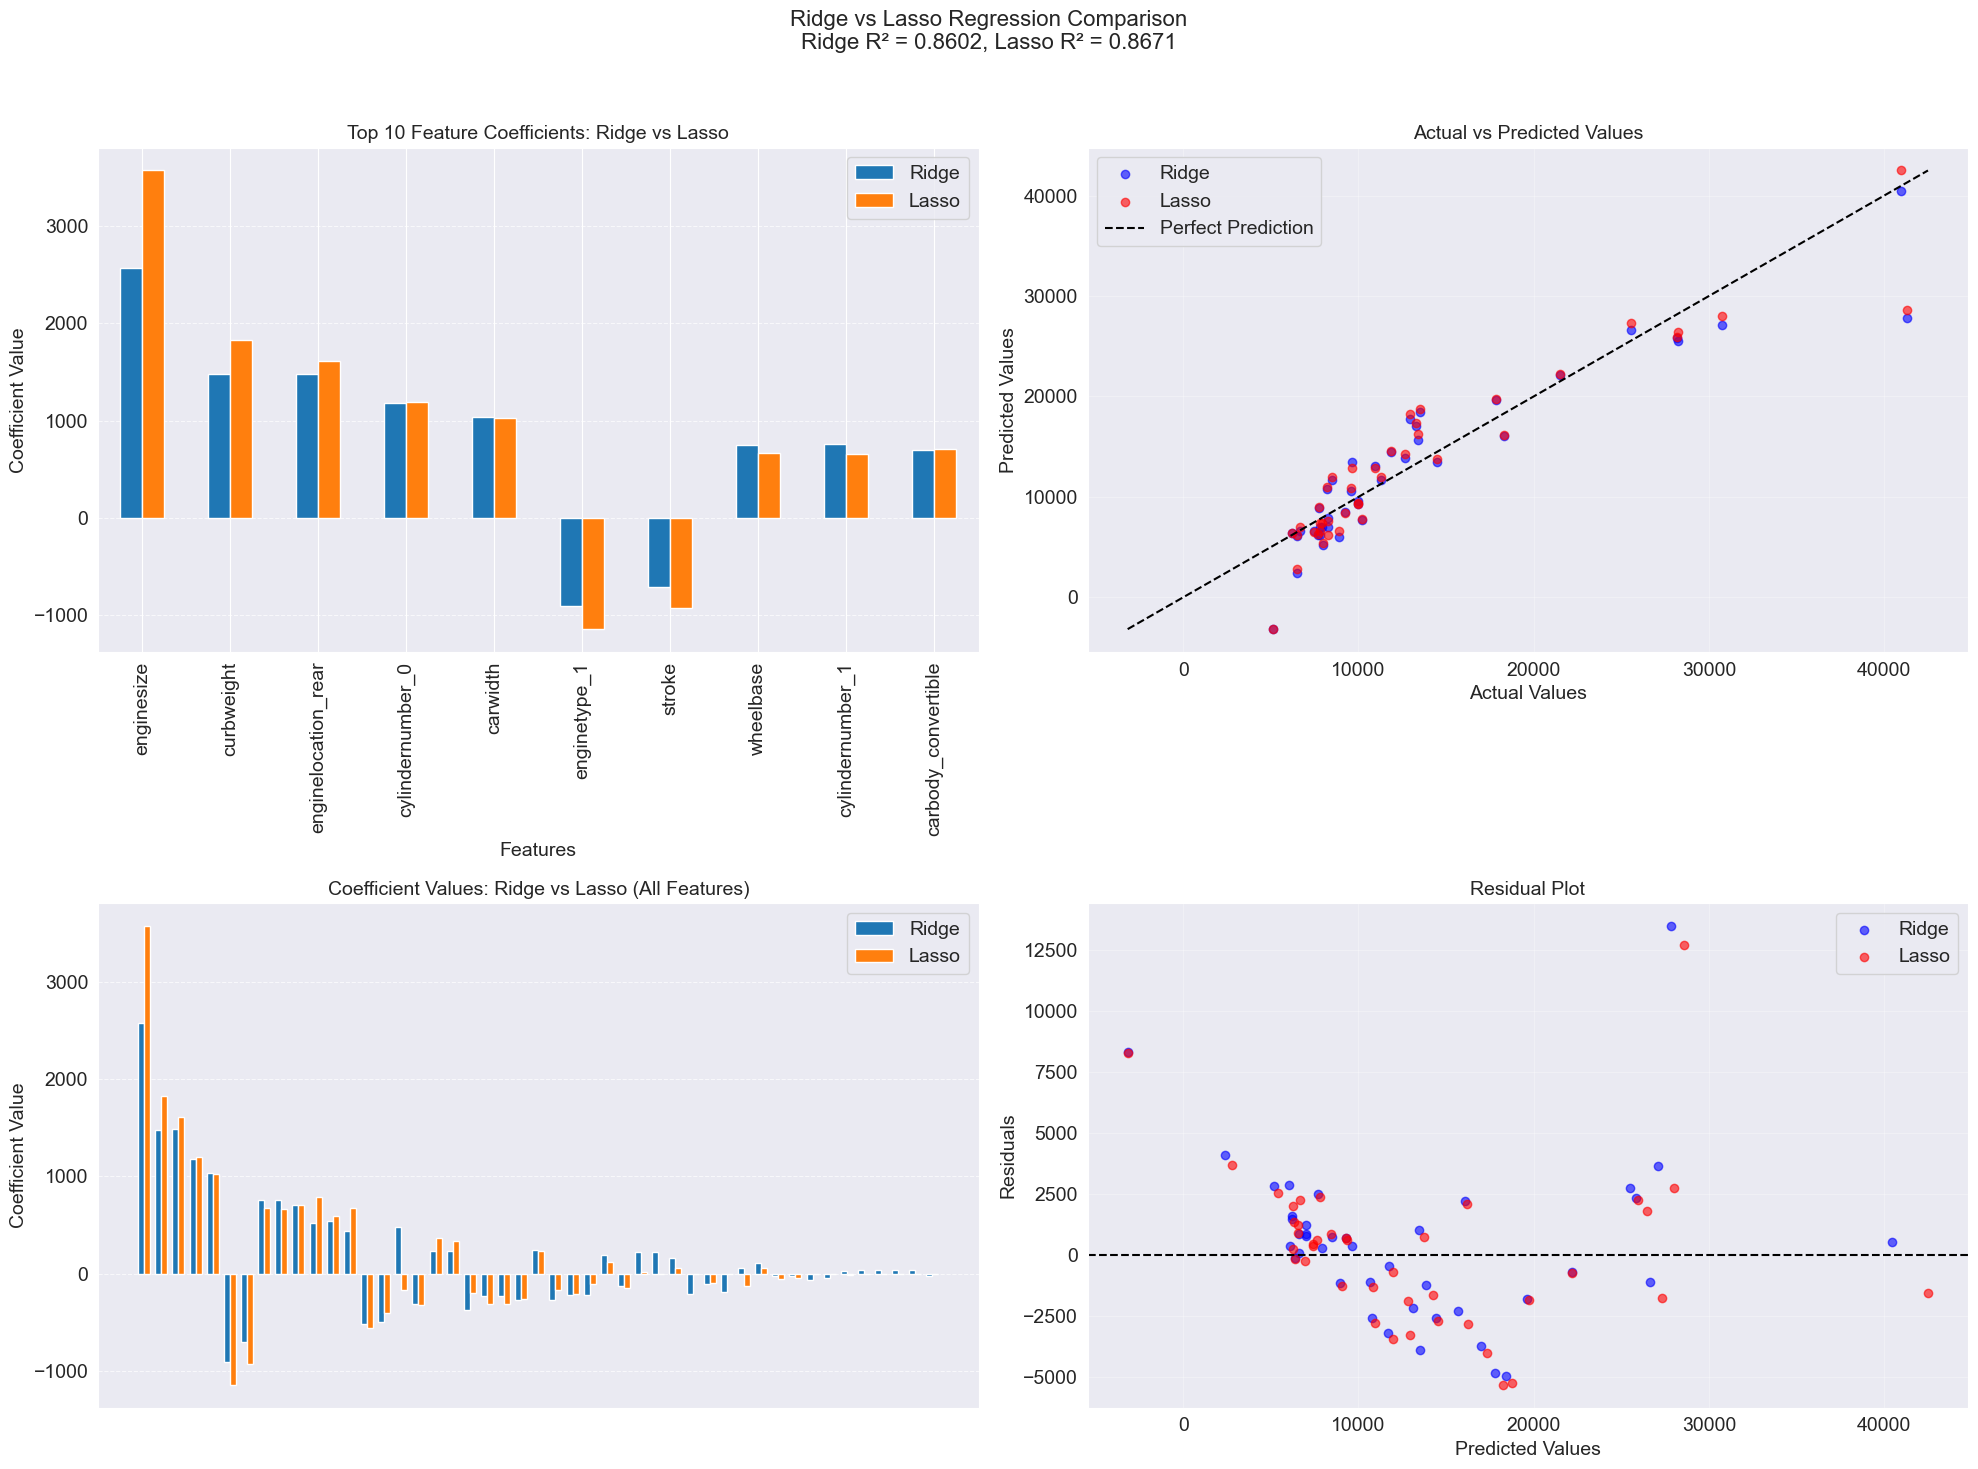

In [100]:
fig = plot_regularization_results(ridge_results, lasso_results, X_test, y_test)
plt.show()

In [102]:
def plot_three_model_comparison(linear_regression_model, linear_metrics, ridge_results, lasso_results, X_train, X_test, y_test):
    """
    Create visualizations comparing Linear Regression, Ridge, and Lasso models.
    
    Parameters:
    - linear_model: Trained LinearRegression model
    - linear_metrics: Metrics dictionary from train_and_evaluate_linear_regression function
    - ridge_results: Results dictionary from Ridge regression
    - lasso_results: Results dictionary from Lasso regression
    - X_train: Training features (for column names)
    - X_test: Test features
    - y_test: Test target values
    """
    # Set up the figure with subplots
    fig = plt.figure(figsize=(20, 16))
    
    # 1. Coefficient comparison plot
    ax1 = plt.subplot2grid((2, 2), (0, 0))
    
    # Create Series for linear regression coefficients
    if hasattr(X_train, 'columns'):  # If X_train is a DataFrame
        linear_coef = pd.Series(linear_metrics['coefficients'], index=X_train.columns)
    else:  # If X_train is a numpy array
        feature_names = [f"Feature_{i}" for i in range(len(linear_metrics['coefficients']))]
        linear_coef = pd.Series(linear_metrics['coefficients'], index=feature_names)
    
    # Get top 10 most important features (by average absolute coefficient)
    linear_coef_abs = linear_coef.abs()
    ridge_coef_abs = ridge_results['coefficients'].abs()
    lasso_coef_abs = lasso_results['coefficients'].abs()
    
    # Average importance between all models
    avg_importance = (linear_coef_abs + ridge_coef_abs + lasso_coef_abs) / 3
    top_features = avg_importance.sort_values(ascending=False).head(10).index
    
    # Create coefficient comparison dataframe
    coef_df = pd.DataFrame({
        'Feature': top_features,
        'Linear': linear_coef[top_features],
        'Ridge': ridge_results['coefficients'][top_features],
        'Lasso': lasso_results['coefficients'][top_features]
    })
    
    # Plot coefficient comparison
    coef_df.plot(x='Feature', y=['Linear', 'Ridge', 'Lasso'], kind='bar', ax=ax1)
    ax1.set_title('Top 10 Feature Coefficients Comparison', fontsize=14)
    ax1.set_ylabel('Coefficient Value')
    ax1.set_xlabel('Features')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    
    # 2. Prediction scatter plot
    ax2 = plt.subplot2grid((2, 2), (0, 1))
    
    # Get predictions
    y_pred_linear = linear_model.predict(X_test)
    y_pred_ridge = ridge_results['model'].predict(X_test)
    y_pred_lasso = lasso_results['model'].predict(X_test)
    
    # Create a dataframe with actual and predicted values
    results_df = pd.DataFrame({
        'Actual': y_test,
        'Linear': y_pred_linear,
        'Ridge': y_pred_ridge,
        'Lasso': y_pred_lasso
    })
    
    # Plot predictions
    ax2.scatter(results_df['Actual'], results_df['Linear'], alpha=0.5, label='Linear', color='green')
    ax2.scatter(results_df['Actual'], results_df['Ridge'], alpha=0.5, label='Ridge', color='blue')
    ax2.scatter(results_df['Actual'], results_df['Lasso'], alpha=0.5, label='Lasso', color='red')
    
    # Add reference line
    min_val = min(results_df['Actual'].min(), results_df[['Linear', 'Ridge', 'Lasso']].min().min())
    max_val = max(results_df['Actual'].max(), results_df[['Linear', 'Ridge', 'Lasso']].max().max())
    ax2.plot([min_val, max_val], [min_val, max_val], 'k--', label='Perfect Prediction')
    
    ax2.set_title('Actual vs Predicted Values', fontsize=14)
    ax2.set_xlabel('Actual Values')
    ax2.set_ylabel('Predicted Values')
    ax2.grid(alpha=0.3)
    ax2.legend()
    
    # 3. Model performance comparison
    ax3 = plt.subplot2grid((2, 2), (1, 0))
    
    # Prepare performance metrics
    linear_r2 = linear_metrics['test']['r2']
    ridge_r2 = ridge_results['test_r2']
    lasso_r2 = lasso_results['test_r2']
    
    # Calculate residuals and non-zero coefficients
    linear_residuals = y_test - y_pred_linear
    ridge_residuals = y_test - y_pred_ridge
    lasso_residuals = y_test - y_pred_lasso
    
    # Count non-zero coefficients
    linear_nonzero = np.sum(np.abs(linear_metrics['coefficients']) > 1e-10)
    ridge_nonzero = np.sum(np.abs(ridge_results['coefficients'].values) > 1e-10)
    lasso_nonzero = np.sum(np.abs(lasso_results['coefficients'].values) > 1e-10)
    
    # Set up bar chart
    models = ['Linear', 'Ridge', 'Lasso']
    r2_scores = [linear_r2, ridge_r2, lasso_r2]
    nonzero_counts = [linear_nonzero, ridge_nonzero, lasso_nonzero]
    
    # Primary axis: R² scores
    ax3.bar(models, r2_scores, color=['green', 'blue', 'red'], alpha=0.7)
    ax3.set_title('Model Performance (R² Score)', fontsize=14)
    ax3.set_ylabel('R² Score')
    ax3.set_ylim([min(0, min(r2_scores) - 0.05), 1])  # Ensure proper y-range
    ax3.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add R² values on top of bars
    for i, v in enumerate(r2_scores):
        ax3.text(i, v + 0.01, f"R² = {v:.4f}", ha='center')
        ax3.text(i, v - 0.08, f"Features: {nonzero_counts[i]}", ha='center', color='white', fontweight='bold')
    
    # 4. Residuals plot
    ax4 = plt.subplot2grid((2, 2), (1, 1))
    
    # Create residuals dataframe
    residuals_df = pd.DataFrame({
        'Linear': linear_residuals,
        'Ridge': ridge_residuals,
        'Lasso': lasso_residuals
    })
    
    # Plot residuals boxplots
    sns.boxplot(data=residuals_df, palette=['green', 'blue', 'red'], ax=ax4)
    ax4.axhline(y=0, color='k', linestyle='--')
    ax4.set_title('Residuals Distribution', fontsize=14)
    ax4.set_ylabel('Residuals')
    ax4.grid(axis='y', alpha=0.3)
    
    # Add RMSE values below model names
    rmse_values = [
        linear_metrics['test']['rmse'],
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso))
    ]
    
    for i, rmse in enumerate(rmse_values):
        ax4.text(i, ax4.get_ylim()[0] * 0.9, f"RMSE: {rmse:.2f}", ha='center')
    
    # Add a main title and adjust layout
    alpha_info = f"Ridge α = {ridge_results['optimal_alpha']:.4f}, Lasso α = {lasso_results['optimal_alpha']:.4f}"
    plt.suptitle(f'Model Comparison: Linear vs Ridge vs Lasso\n{alpha_info}', 
                fontsize=16, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    

    return fig



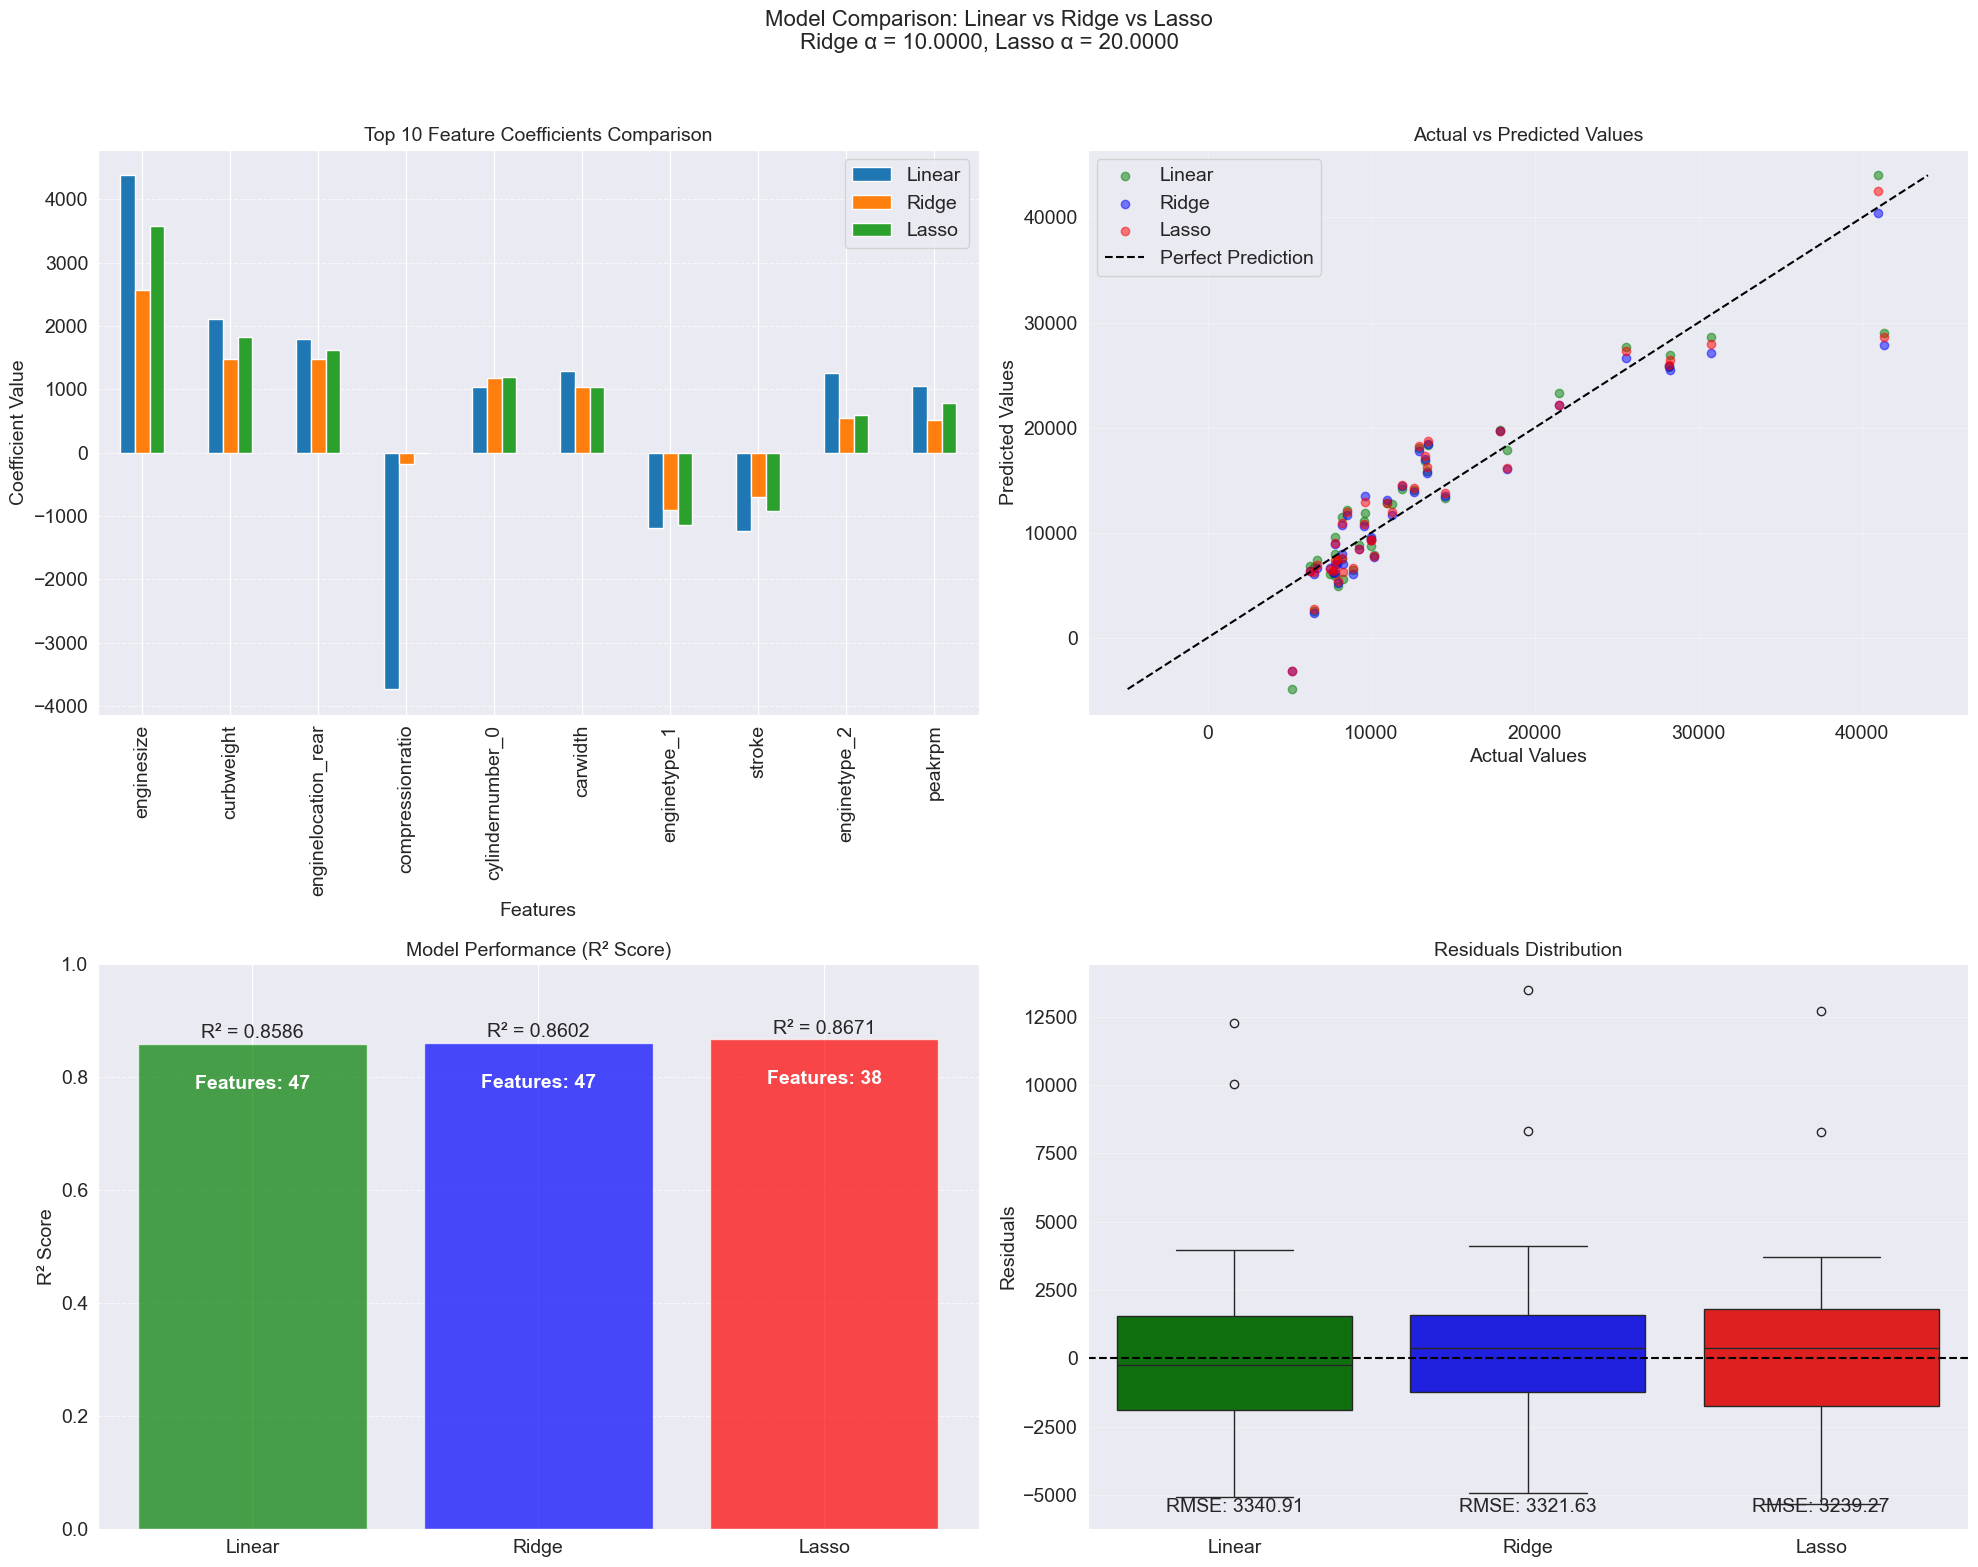

In [104]:
fig = plot_three_model_comparison(linear_regression_model, metrics, ridge_results, lasso_results, X_train, X_test, y_test)
plt.show()

## Development Process

Here, I outline the steps I took to build the project and why I made certain decisions.
### **Step 1:** Planning and Understanding the Dataset

 I began by loading the dataset and using car_df.info() to inspect its structure. I identified 26 features, including 10 categorical and 13 numerical columns (excluding car_ID and price).

 Understanding the dataset’s composition was critical to decide on preprocessing strategies. Knowing there were no missing values allowed me to focus on encoding and scaling.

### **Step 2:** Researching Encoding Methods

 I researched encoding techniques for categorical features, especially CarName and its colleagues, which had many unique values. I explored one-hot encoding, label encoding, and binary encoding, ultimately choosing binary encoding.

 I initially considered one-hot encoding but realized it would create too many columns for CarName and its colleagues, making the model inefficient. Binary encoding was a compromise that reduced dimensionality while retaining information, which I learned about through online resources and tutorials.

### **Step 3:** Data Preprocessing

I split the data into training and test sets, encoded categorical features using BinaryEncoder, and scaled numerical features with StandardScaler. I faced issues with mismatched columns between training and test sets after encoding.

 Splitting the data first was a best practice I learned to avoid data leakage. The column mismatch issue was a significant hurdle, but it taught me the importance of consistent preprocessing pipelines. I resolved it by ensuring the encoder was fitted only on the training data.



### **Step 4:** Model Training and Evaluation

I trained Linear Regression, Ridge, and Lasso models, evaluated them using R², MSE, and MAE, and attempted to visualize the results.

I chose multiple models to compare their performance and understand the impact of regularization. The evaluation metrics helped me assess both fit and error, while visualizations were intended to make my findings accessible to others.



### **Step 5:** Debugging and Iteration

 I encountered errors, such as the undefined lasso_model in the RFE cell, and spent time debugging preprocessing issues like column mismatches.

 Debugging was a big part of the process, especially during preprocessing. These challenges forced me to revisit my code and research solutions, improving my understanding of machine learning workflows.

## Challenges and Solutions





Challenge 1: Encoding High-Cardinality Features





Problem: The CarName feature had many unique values, and one-hot encoding would have created too many columns, risking model inefficiency.



Solution: I researched encoding methods and chose binary encoding, which reduced dimensionality while preserving information. This required installing and learning to use the category_encoders library.



Challenge 2: Mismatched Columns After Encoding





Problem: After splitting the data and applying binary encoding, the training and test sets had different numbers of columns due to unseen categories in the test set.



Solution: I learned that the encoder must be fitted on the training data and then used to transform the test data. I adjusted my preprocessing pipeline to ensure consistency, which was time-consuming but critical for model training.



Challenge 3: Notebook Errors and Organization





Problem: The RFE cell threw a NameError because lasso_model wasn’t defined, likely due to running cells out of order or incomplete code.



Solution: I recognized the need for better notebook organization, such as defining all models before evaluation steps. In the future, I’ll use clearer cell dependencies and test code incrementally.

### Conclusion





Summary: This project was a deep dive into machine learning, from data preprocessing to model evaluation. I successfully loaded and explored the dataset, preprocessed it despite significant challenges, and trained three regression models to predict car prices. The visualizations and metrics helped me compare model performance.


Lessons Learned: I learned the importance of researching preprocessing techniques, especially for high-cardinality features. The column mismatch issue taught me about data leakage and consistent pipelines. Debugging errors improved my problem-solving skills, and I realized the value of organized code in Jupyter Notebooks.


Future Improvements: I’d like to complete the RFE analysis to validate feature selection, explore other encoding methods (e.g., target encoding), and try more advanced models like Random Forest or XGBoost. Adding feature selection earlier in the pipeline could also improve efficiency.

### References


Pandas documentation: https://pandas.pydata.org/docs/



Scikit-learn documentation: https://scikit-learn.org/stable/



Category Encoders documentation: https://contrib.scikit-learn.org/category_encoders/



Online tutorials on encoding categorical variables (e.g., Medium, Towards Data Science).